# Init

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

from src.general_analysis.engine import AnalysisEnvironment
from src.barter.regression_models import create_regression_runner
from src.utils import interactive_regression_results_selector

# Load data

In [3]:
env = AnalysisEnvironment(active_analysis='barter_deals', sandbox_mode=False)

# Load everything
final_df, og_df = env.load_data(use_cache=True, force_refresh=False)
pm, prompt_map = env.load_prompts()

Loading files for analysis Barter Deals Analysis
⚡ Loading cached DataFrame from C:\Users\Wouter Barter\Documents\AI_thesis\results\BARTER_DEALS\BARTER_DEALS_analysis_ready.pkl...
PromptManager initialized with folder: ..\prompts\PromptSuites\BARTER_DEALS
Scanning 7 suites from ..\prompts\PromptSuites\BARTER_DEALS...
Loaded 7 PromptSuites


In [4]:
og_df

,applicants_applications_count,content_types,deal_id,main_image,min_social_media_followers,deal_tags,live_since,first_application_at,last_application_at,company_locations,...,req_facebook,platform_count,platform_strategy,raw_input_word_count,log_apps_after_7_days,log_deal_value,log_title_word_count,log_text_word_count,log_requirements_word_count,log_competitor_density
0,10,"[{'id': 20, 'name': 'Beauty', 'slug': 'Heart'}...",01968a82-9063-00c8-a178-56bbf92db1d9,uploads/deals/01968a82-24b9-ffff-5a8e-92dcf0a8...,5000,None,2025-06-02 19:33:07.997987,2025-05-01 13:31:16.610408,2025-05-13 21:23:16.606380,None,...,0,1,Instagram_Only,53,2.302585,5.669881,1.945910,3.258097,3.135494,0.000000
1,8,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",01968af1-f78d-00c8-d1f0-b6ea4e7f3251,uploads/deals/01968af0-f987-ffff-16c0-e833ccff...,2500,None,2025-05-01 08:23:55.697617,2025-05-01 12:16:14.626582,2025-05-04 19:08:46.280439,"[{""id"": ""01KERJ26D105FM72RARYSMA2AW"", ""name"": ...",...,0,2,IG_and_TikTok,68,2.197225,0.000000,1.945910,3.401197,3.526361,1.609438
2,21,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'...",01968b03-f7b6-00c8-4ac5-f92b235aa10d,uploads/deals/01968aff-9f67-ffff-dea2-0def50c9...,10000,None,2025-05-01 08:43:35.350826,2025-05-01 10:54:50.019465,2025-11-19 22:40:24.416572,"[{""id"": ""01KERHSGS605FV5KNYGEBG6FME"", ""name"": ...",...,0,1,Instagram_Only,96,1.609438,NaN,2.079442,3.688879,3.931826,1.386294
3,21,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'...",01968b0b-b879-00c8-470e-044f1e26e293,uploads/deals/01968b0b-62d6-ffff-2af8-f62cb203...,5000,None,2025-05-01 08:52:03.597239,2025-05-01 17:24:20.747332,2025-12-01 09:35:34.914363,"[{""id"": ""01KERHSGS605FV5KNYGEBG6FME"", ""name"": ...",...,0,1,Instagram_Only,67,1.386294,NaN,2.197225,3.688879,3.044522,1.386294
4,10,"[{'id': 21, 'name': 'Fashion', 'slug': 'Dress'...",01968b1a-621a-00c8-eb2a-36b7f3ee8694,uploads/deals/01968b19-9ced-ffff-b45c-85efb252...,5000,None,2025-05-01 09:08:04.376892,2025-05-01 10:18:05.456020,2025-11-19 22:36:57.476841,None,...,0,1,Instagram_Only,138,1.098612,NaN,2.197225,4.488636,3.761200,1.386294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3419,37,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019cd2c5-58c5-00c8-7191-1b4d225c997d,uploads/deals/019cd2c3-eb0b-ffff-f986-e5f5e04a...,10000,None,2026-03-09 13:24:34.783518,2026-03-09 13:31:45.295401,2026-03-23 10:42:09.855831,None,...,0,1,TikTok_Only,296,3.433987,0.000000,1.791759,4.543295,5.293305,1.609438
3420,309,"[{'id': 39, 'name': 'Experiences', 'slug': 'Te...",019cd2f6-0b38-00c8-8632-d21f82239d99,uploads/deals/019cd2f4-ea18-ffff-22cf-7f051c10...,2500,None,2026-03-09 14:17:46.161271,2026-03-09 14:20:45.600022,2026-03-23 23:28:29.743306,None,...,0,2,IG_and_TikTok,344,5.529429,7.467942,2.197225,5.690359,3.737670,1.609438
3421,60,"[{'id': 41, 'name': 'Activities', 'slug': 'per...",019cd345-8059-00c8-4f76-2022ec342341,uploads/deals/019cd344-fbc3-ffff-a966-1937e0f6...,2500,None,2026-03-09 16:05:33.903411,2026-03-09 16:15:45.752355,2026-03-23 21:20:47.153978,None,...,0,2,IG_and_TikTok,200,4.007333,0.000000,2.302585,4.852030,4.174387,0.000000
3422,2,"[{'id': 29, 'name': 'UGC', 'slug': 'Film-Strip...",019cd3d5-cb91-00c8-8ba0-4dc62e4c938e,uploads/deals/019cd3d3-5df8-ffff-d3fd-6aeeda86...,2500,None,2026-03-09 18:29:41.700566,2026-03-12 06:35:48.124634,2026-03-16 22:29:27.224174,None,...,0,0,Unspecified,170,0.693147,4.615121,1.791759,3.951244,4.744932,0.000000


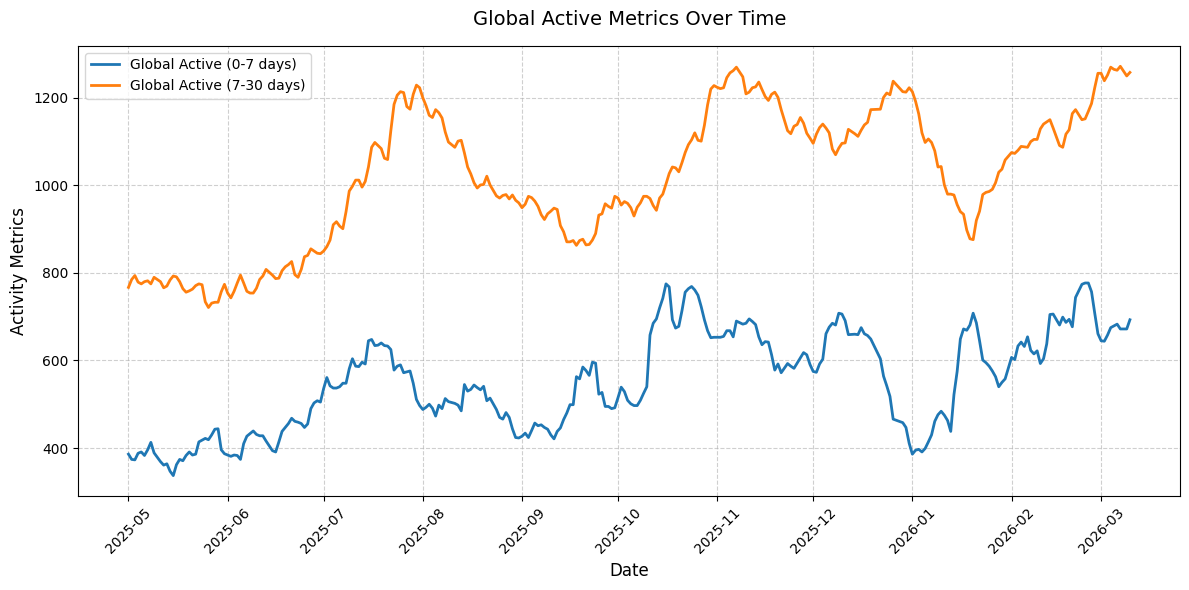

In [5]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'date' column is in datetime format
og_df["date"] = pd.to_datetime(og_df["date"])

# Sort the DataFrame by date to ensure the line plots correctly
og_df = og_df.sort_values("date")

# Create the plot using subplots (avoiding .figure() as per guidelines)
fig, ax = plt.subplots(figsize=(12, 6))

# Plot both columns over time
ax.plot(
    og_df["date"],
    og_df["global_active_0_7d"],
    label="Global Active (0-7 days)",
    linewidth=2,
)
ax.plot(
    og_df["date"],
    og_df["global_active_7_30d"],
    label="Global Active (7-30 days)",
    linewidth=2,
)

# Customize chart details
ax.set_title("Global Active Metrics Over Time", fontsize=14, pad=15)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Activity Metrics", fontsize=12)
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.6)

# Rotate date labels to prevent overlap and ensure readability
plt.xticks(rotation=45)
plt.tight_layout()

# Save the generated plot
# plt.savefig("global_active_plot.png")

# Data pre-processing

## Updated at minus created at

In [6]:
def create_time_to_update_hours_col(df):

    df["time_to_update_hours"] = (
        df["updated_at"] - df["created_at"]
    ).dt.total_seconds() / 3600

    # small tolerance because created_at and updated_at may differ by seconds automatically
    tol = 1 / 60  # one minute

    df["was_updated"] = df["time_to_update_hours"] > tol

    df["update_window"] = pd.cut(
        df["time_to_update_hours"],
        bins=[-0.001, tol, 1, 24, 168, float("inf")],
        labels=[
            "no_or_instant_update",
            "within_1h",
            "1h_to_24h",
            "1d_to_7d",
            "after_7d"
        ],
        include_lowest=True
    )
    return df


og_df = create_time_to_update_hours_col(og_df)
final_df = create_time_to_update_hours_col(final_df)

In [7]:
# og_df['updated_at_minus_created_at'] = og_df['updated_at'] - og_df['created_at']
# og_df['duration_hours'] = (og_df['updated_at'] - og_df['created_at']).dt.total_seconds() / 3600


# 1. Calculate raw duration in hours (or days)
og_df['exposure_hours'] = (pd.to_datetime(
    og_df['updated_at']) - pd.to_datetime(og_df['created_at'])).dt.total_seconds() / 3600

# 2. Clip at a minimum threshold to prevent log(0) or negative time anomalies
# A deal online for 5 minutes is treated as online for 1 hour to stabilize the math
og_df['exposure_hours'] = og_df['exposure_hours'].clip(lower=1.0)

# 3. Apply the natural logarithm
og_df['log_exposure'] = np.log(og_df['exposure_hours'])

In [8]:
import numpy as np

# 1. Calculate raw duration in hours
raw_hours = (pd.to_datetime(
    og_df['updated_at']) - pd.to_datetime(og_df['created_at'])).dt.total_seconds() / 3600

# 2. Handle missing updated_at (assume deals without an end date survived the full 7 days)
raw_hours = raw_hours.fillna(168.0)

# 3. Cap strictly between 1 hour and 168 hours
# Lower bound prevents log(0), upper bound aligns with 'apps_after_7_days'
og_df['exposure_hours'] = raw_hours.clip(lower=1.0, upper=168.0)

# 4. Apply log link
og_df['log_exposure'] = np.log(og_df['exposure_hours'])

In [9]:
import numpy as np

# 1. Calculate raw duration in hours
raw_hours = (pd.to_datetime(
    final_df['updated_at']) - pd.to_datetime(final_df['created_at'])).dt.total_seconds() / 3600

# 2. Handle missing updated_at (assume deals without an end date survived the full 7 days)
raw_hours = raw_hours.fillna(168.0)

# 3. Cap strictly between 1 hour and 168 hours
# Lower bound prevents log(0), upper bound aligns with 'apps_after_7_days'
final_df['exposure_hours'] = raw_hours.clip(lower=1.0, upper=168.0)

# 4. Apply log link
final_df['log_exposure'] = np.log(final_df['exposure_hours'])

## Market scope

In [10]:
import pandas as pd
import numpy as np


def create_market_scope(df: pd.DataFrame) -> pd.DataFrame:
    """Calculates the Tier-based market scope proxy."""
    df = df.copy()

    def _get_tier(row):
        countries = row.get('accepted_countries', [])
        if not isinstance(countries, (list, np.ndarray)):
            countries = []
        c_set = set(countries)

        # 1. Multi-country / Broad Markets
        if len(c_set) > 1:
            if "NLD" in c_set:
                return "Tier1_NLD_international"
            else:
                # Properly captures broad EU deals like ['GBR', 'BEL', 'DEU', 'FRA']
                return "Tier1_NonNLD_international"

        # 2. Single-Country Specific Markets
        if c_set == {"NLD"}:
            return "Tier2_NLD_only"
        elif c_set == {"BEL"}:
            return "Tier3_BEL_Only"
        elif "DEU" in c_set:
            return "Tier4_Germany"

        # 3. Fallback for unexpected single countries (e.g., {"GBR"} only)
        return "Tier5_Other"

    df['market_scope'] = df.apply(_get_tier, axis=1)
    return df


og_df = create_market_scope(og_df)
final_df = create_market_scope(final_df)

## Filter out zero-word text rows

In [11]:
final_df = final_df[~((final_df['text_word_count'] < 2) &
                      (final_df['requirements_word_count'] < 2))]

## Human readable cols

In [12]:
# Human readable prompt names

# prompt_map_clean = {
#     'dbadc59142e9': 'Holistic Naive (1D)',
#     '38c4714f0e3a': 'Holistic Informed (3D)',
#     '1e1ff82a28e2': 'Formative (10D)'
# }

prompt_map_clean = {
    'dbadc59142e9': 'Holistic Naive',
    '38c4714f0e3a': 'Macro-Formative',
    '1e1ff82a28e2': 'Formative'
}


final_df['prompt_name'] = final_df['prompt_id'].map(prompt_map_clean)


# Analysis group concatenation

final_df['analysis_group'] = final_df['model_name'] + \
    "_" + final_df['prompt_id']
final_df['analysis_group_full'] = final_df['model_name'] + "_" + \
    final_df['prompt_id'] + "_" + final_df['dimension_name']
final_df['analysis_group_named'] = final_df['model_name'] + \
    "_" + final_df['prompt_name'] + "_" + final_df['prompt_id']

# Human readable model col
model_map_clean = {
    'google/gemma-4-E2B-it': "Gemma 4",
    'meta-llama/Llama-3.2-3B-Instruct': "Llama 3.2",
    'Qwen/Qwen3-4B-Instruct-2507': "Qwen 3",
    'Qwen/Qwen3.5-4B': "Qwen 3.5"
}
final_df['model_name_clean'] = final_df['model_name'].map(model_map_clean)


# Clean dimension names
dim_map_clean = {
    # Holistic
    'deal_pitch_overall_deal_attractiveness': 'Holistic\nDeal Attractiveness',

    # Macro-Formative
    'deal_pitch_overall_reward_value': 'Macro-Formative\nReward Value',
    'deal_pitch_overall_task_demand': 'Macro-Formative\nTask Demand',
    'deal_pitch_overall_pitch_quality': 'Macro-Formative\nPitch Quality',

    # Formative
    'deal_pitch_brand_prestige': 'Formative\nBrand Prestige',
    'deal_pitch_perceived_economic_value': 'Formative\nPerceived Economic Value',
    'deal_pitch_creator_brand_alignment': 'Formative\nCreator Brand Alignment',
    'deal_pitch_functional_utility': 'Formative\nFunctional Utility',
    'deal_pitch_product_universality': 'Formative\nProduct Universality',
    'deal_pitch_workload_volume': 'Formative\nWorkload Volume',
    'deal_pitch_creative_restrictiveness': 'Formative\nCreative Restrictiveness',
    'deal_pitch_call_to_action_strength': 'Formative\nCall To Action Strength',
    'deal_pitch_rhetorical_objectivity': 'Formative\nRhetorical Objectivity',
    'deal_pitch_proposition_clarity': 'Formative\nProposition Clarity'
}

# Automatically extract the exact values to ensure a 1:1 match
plot_order = list(dim_map_clean.values())

final_df['dimension_name_clean'] = final_df['dimension_name'].map(
    dim_map_clean)


# Human readable analysis group/ experimental group
final_df['analysis_group_full_clean'] = final_df['model_name_clean'] + \
    ": " + final_df['dimension_name_clean'] + \
    "(" + final_df['prompt_name'] + ")"

final_df['analysis_group_clean'] = final_df['model_name_clean'] + \
    " " + final_df['prompt_name']

## Other features

In [13]:
og_df['raw_input_word_count'] = og_df['title_word_count'] + \
    og_df['text_word_count'] + og_df['requirements_word_count']

og_df['log_raw_input_word_count'] = np.log1p(
    og_df['raw_input_word_count'])


og_df['raw_input_word_count_squared'] = np.square(
    og_df['raw_input_word_count'])

In [14]:
final_df['raw_input_word_count'] = final_df['title_word_count'] + \
    final_df['text_word_count'] + final_df['requirements_word_count']


final_df['log_raw_input_word_count'] = np.log1p(
    final_df['raw_input_word_count'])

final_df['raw_input_word_count_squared'] = np.square(
    final_df['raw_input_word_count'])

In [15]:
og_df['text_word_count'].describe()

count    2962.000000
mean       82.820729
std        74.110034
min         1.000000
25%        39.000000
50%        65.000000
75%       105.000000
max      1000.000000
Name: text_word_count, dtype: float64

In [16]:
final_df['length_bucket'] = pd.qcut(final_df['raw_input_word_count'], q=4,
                                    labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

og_df['length_bucket'] = pd.qcut(og_df['raw_input_word_count'], q=4,
                                 labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

final_df['requirements_length_bucket'] = pd.qcut(final_df['requirements_word_count'], q=4,
                                                 labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

og_df['requirements_length_bucket'] = pd.qcut(og_df['requirements_word_count'], q=4,
                                              labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

final_df['body_length_bucket'] = pd.qcut(final_df['text_word_count'], q=4,
                                         labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

og_df['body_length_bucket'] = pd.qcut(og_df['text_word_count'], q=4,
                                      labels=['1. Short', '2. Medium-Short', '3. Medium-Long', '4. Long'])

# final_df_long = final_df[final_df['length_bucket'].isin(
#     ['3. Medium-Long', '4. Long'])]

In [17]:
plot_order = list(dim_map_clean.values())

# prompt_order = [
#     'Holistic Naive (1D)', 'Holistic Informed (3D)', 'Formative (10D)']
prompt_order = ['Holistic Naive', 'Macro-Formative', 'Formative']

## Balance datasets

In [18]:
import pandas as pd


def enforce_sample_equivalence(
    og_df: pd.DataFrame,
    final_df: pd.DataFrame,
    id_col: str = 'deal_id'
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Isolates the strict intersection of unique identifiers across datasets 
    while preserving original indices for downstream structural mapping.
    """
    # Extract structural intersection
    valid_ids = set(og_df[id_col]).intersection(set(final_df[id_col]))

    # Restrict samples to the intersection without resetting the index
    og_balanced = og_df[og_df[id_col].isin(valid_ids)]
    final_balanced = final_df[final_df[id_col].isin(valid_ids)]

    # Report attrition diagnostics
    print(
        f"Pre-alignment  -> og_df rows: {len(og_df)} | final_df rows: {len(final_df)}")
    print(f"Post-alignment -> Unique IDs retained: {len(valid_ids)}")
    print(
        f"Attrition      -> og_df lost: {len(og_df) - len(og_balanced)} rows | final_df lost: {len(final_df) - len(final_balanced)} rows")

    return og_balanced, final_balanced


# Execution
og_df, final_df = enforce_sample_equivalence(og_df, final_df)

Pre-alignment  -> og_df rows: 2962 | final_df rows: 165760
Post-alignment -> Unique IDs retained: 2960
Attrition      -> og_df lost: 2 rows | final_df lost: 0 rows


# Final EDA

## Distribution of EV and Entropy

In [19]:
from src.general_analysis.tables import rating_entropy_distribution
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

In [20]:
mean_entr_distribution = rating_entropy_distribution(final_df)

print(mean_entr_distribution.to_latex(
    column_format='lcc',
    caption='Scale Utilization and Entropy Calibration by Model Architecture.',
    label='tab:scale_utilization_barter',
    escape=False
))

\begin{table}
\caption{Scale Utilization and Entropy Calibration by Model Architecture.}
\label{tab:scale_utilization_barter}
\begin{tabular}{lcc}
\toprule
 & Rating: Mean (SD) & Entropy: Mean (SD) \\
Model &  &  \\
\midrule
Gemma 4 & 3.54 (1.00) & 0.30 (0.17) \\
Llama 3.2 & 4.29 (0.40) & 0.67 (0.08) \\
Qwen 3 & 4.14 (1.01) & 0.18 (0.13) \\
Qwen 3.5 & 3.68 (0.79) & 0.66 (0.09) \\
\bottomrule
\end{tabular}
\end{table}



In [21]:
# fig = plot_rating_distributions_by_architecture(
#     final_df=final_df,
#     plot_order=plot_order,
#     dim_map_clean=dim_map_clean,
#     score_col='mean_rating',
#     rating_range=(1, 7),
#     save_path='../latex_thesis/figures/barter_rating_distributions.pdf',
#     show=False
# )

## Verbosity Bias

In [22]:
from src.general_analysis.tables import verbosity_bias_table, summarize_verbosity_bias
sections = {
    'Total Input': 'raw_input_word_count'}

verbosity_df = verbosity_bias_table(
    df=final_df,
    sections=sections,
    min_abs_d=0  # only medium or larger effects
)
verbosity_df

,Model,Dimension,Text Section,Mean Q3,Mean Q4,Raw Shift,Cohen's d,Absolute Cohen's d,N Q3,N Q4
0,Llama 3.2,Macro-Formative\nReward Value,Total Input,4.79,5.08,0.30,0.85,0.85,744,736
1,Llama 3.2,Holistic\nDeal Attractiveness,Total Input,5.20,5.44,0.24,0.76,0.76,744,736
2,Llama 3.2,Macro-Formative\nTask Demand,Total Input,3.84,4.04,0.20,0.69,0.69,744,736
3,Llama 3.2,Formative\nPerceived Economic Value,Total Input,4.37,4.64,0.27,0.64,0.64,744,736
4,Llama 3.2,Formative\nBrand Prestige,Total Input,4.19,4.45,0.25,0.63,0.63,744,736
5,Llama 3.2,Formative\nWorkload Volume,Total Input,3.92,4.06,0.14,0.61,0.61,744,736
6,Llama 3.2,Macro-Formative\nPitch Quality,Total Input,4.76,4.94,0.18,0.59,0.59,744,736
7,Llama 3.2,Formative\nCall To Action Strength,Total Input,4.92,5.11,0.20,0.55,0.55,744,736
8,Llama 3.2,Formative\nFunctional Utility,Total Input,4.31,4.51,0.20,0.53,0.53,744,736
9,Llama 3.2,Formative\nProposition Clarity,Total Input,4.59,4.71,0.12,0.48,0.48,744,736


In [23]:
verbosity_summary = summarize_verbosity_bias(
    bias_df=verbosity_df,
    model_col="Model",
    abs_d_col="Absolute Cohen's d",
    combine_medium_large=False
)

print(
    verbosity_summary.to_latex(
        index=False,
        escape=False,
        column_format="lccccccc",
        caption="Summary of Barter Deals Verbosity-Bias Diagnostics",
        label="tab:verbosity_bias_barter"
    )
)

\begin{table}
\caption{Summary of Barter Deals Verbosity-Bias Diagnostics}
\label{tab:verbosity_bias_barter}
\begin{tabular}{lccccccc}
\toprule
Model & Mean $|d|$ & Max $|d|$ & N & Negligible & Small & Medium & Large \\
\midrule
Gemma 4 & 0.17 & 0.46 & 14 & 8 & 6 & 0 & 0 \\
Llama 3.2 & 0.53 & 0.85 & 14 & 1 & 4 & 8 & 1 \\
Qwen 3 & 0.20 & 0.47 & 14 & 8 & 6 & 0 & 0 \\
Qwen 3.5 & 0.17 & 0.43 & 14 & 10 & 4 & 0 & 0 \\
\bottomrule
\end{tabular}
\end{table}



## VIF

In [24]:
from src.barter.regression_validation import PredictiveValidityExplorer
from src.utils import interactive_dataframe_selector
from src.general_analysis.diagnostics import compact_vif_threshold_summary
from src.barter.regression_models import create_regression_runner


CONTENT_TYPE_COL = 'macro_category'
CATEGORICALS = ['market_scope', CONTENT_TYPE_COL,
                'year_month', 'platform_strategy', 'requirements_length_bucket', 'body_length_bucket']

CONTINUOUS = ['competitor_density']
BINARIES = ['strict_follower_requirement']

EXPERIMENTAL_GROUPS = ['model_name_clean', 'prompt_name']

runner_mean = create_regression_runner(
    target_col='apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin',
)


vif_df = runner_mean.compute_baseline_vifs(df=og_df,
                                           cat_vars=CATEGORICALS,
                                           bin_vars=BINARIES,
                                           num_vars=CONTINUOUS,
                                           #   predictor_names=['z_mean_rating']
                                           )

vif_table = compact_vif_threshold_summary(vif_df).copy()

# # Optional: make labels thesis-clean
# vif_table["Group"] = (
#     vif_table["Group"]
#     .str.replace("_", " ", regex=False)
# )

latex_vif_table = vif_table.to_latex(
    index=False,
    column_format="lccrrl",
    caption="VIF Diagnostics for Barter Deals Formative Specifications",
    label="tab:VIF_barter",
    escape=False
)

print(latex_vif_table)

\begin{table}
\caption{VIF Diagnostics for Barter Deals Formative Specifications}
\label{tab:VIF_barter}
\begin{tabular}{lccrrl}
\toprule
Group & Max VIF & Mean VIF & N VIF > 5 & N VIF > 10 & Multicollinearity \\
\midrule
baseline & 5.09 & 2.04 & 1 & 0 & Moderate \\
\bottomrule
\end{tabular}
\end{table}



In [25]:

vif_df = runner_mean.compute_vifs(df=final_df,
                                  cat_vars=[],
                                  bin_vars=[],
                                  num_vars=[],
                                  predictor_names=['z_mean_rating']
                                  )

vif_table = compact_vif_threshold_summary(vif_df).copy()

latex_vif_table = vif_table.to_latex(
    index=False,
    column_format="lccrrl",
    caption="VIF Diagnostics for Barter Deals Formative Specifications",
    label="tab:VIF_barter",
    escape=False
)

print(latex_vif_table)

\begin{table}
\caption{VIF Diagnostics for Barter Deals Formative Specifications}
\label{tab:VIF_barter}
\begin{tabular}{lccrrl}
\toprule
Group & Max VIF & Mean VIF & N VIF > 5 & N VIF > 10 & Multicollinearity \\
\midrule
Gemma 4 Formative & 1.79 & 1.36 & 0 & 0 & Limited \\
Gemma 4 Macro-Formative & 1.70 & 1.49 & 0 & 0 & Limited \\
Llama 3.2 Formative & 3.70 & 2.54 & 0 & 0 & Limited \\
Llama 3.2 Macro-Formative & 4.20 & 2.99 & 0 & 0 & Limited \\
Qwen 3 Formative & 1.97 & 1.49 & 0 & 0 & Limited \\
Qwen 3 Macro-Formative & 1.34 & 1.25 & 0 & 0 & Limited \\
Qwen 3.5 Formative & 2.07 & 1.58 & 0 & 0 & Limited \\
Qwen 3.5 Macro-Formative & 1.34 & 1.26 & 0 & 0 & Limited \\
\bottomrule
\end{tabular}
\end{table}



# General EDA

## Distribrution across rating scale

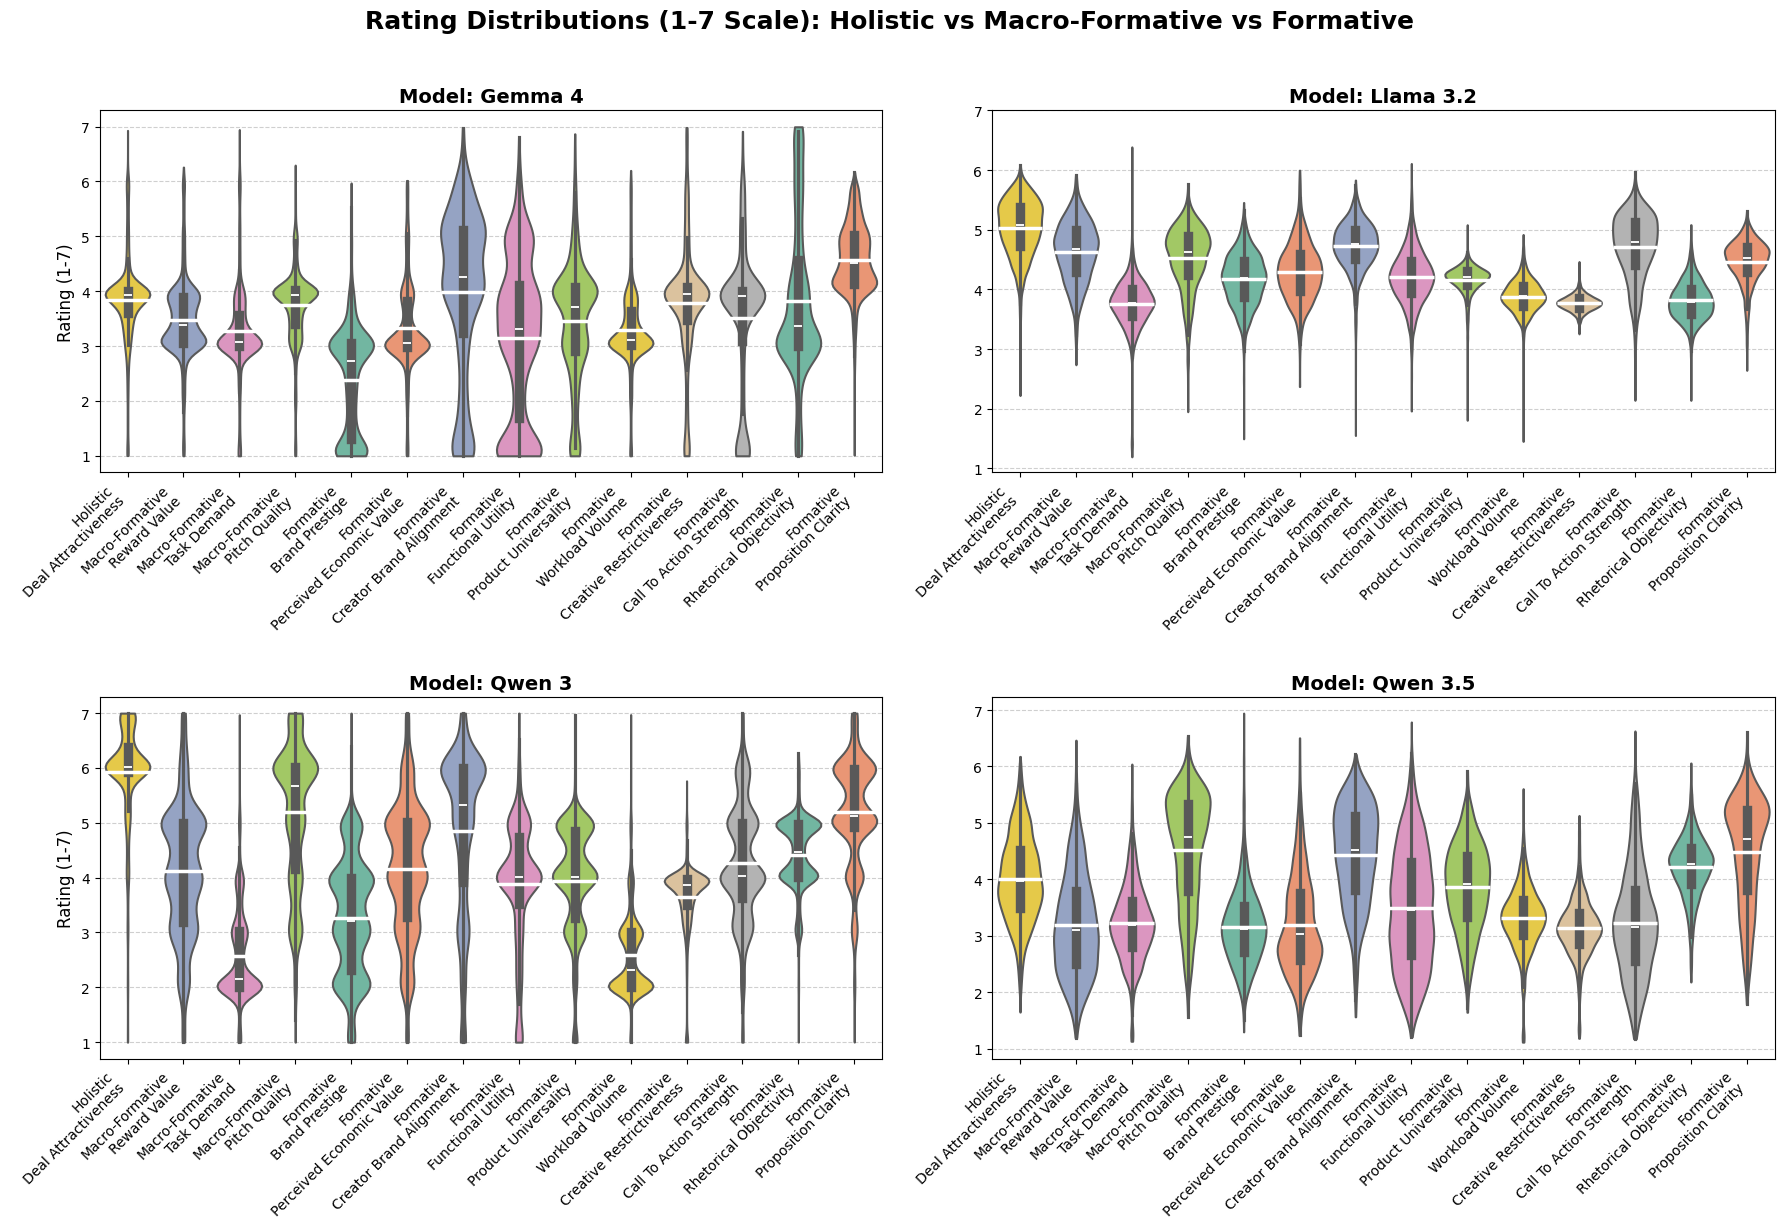

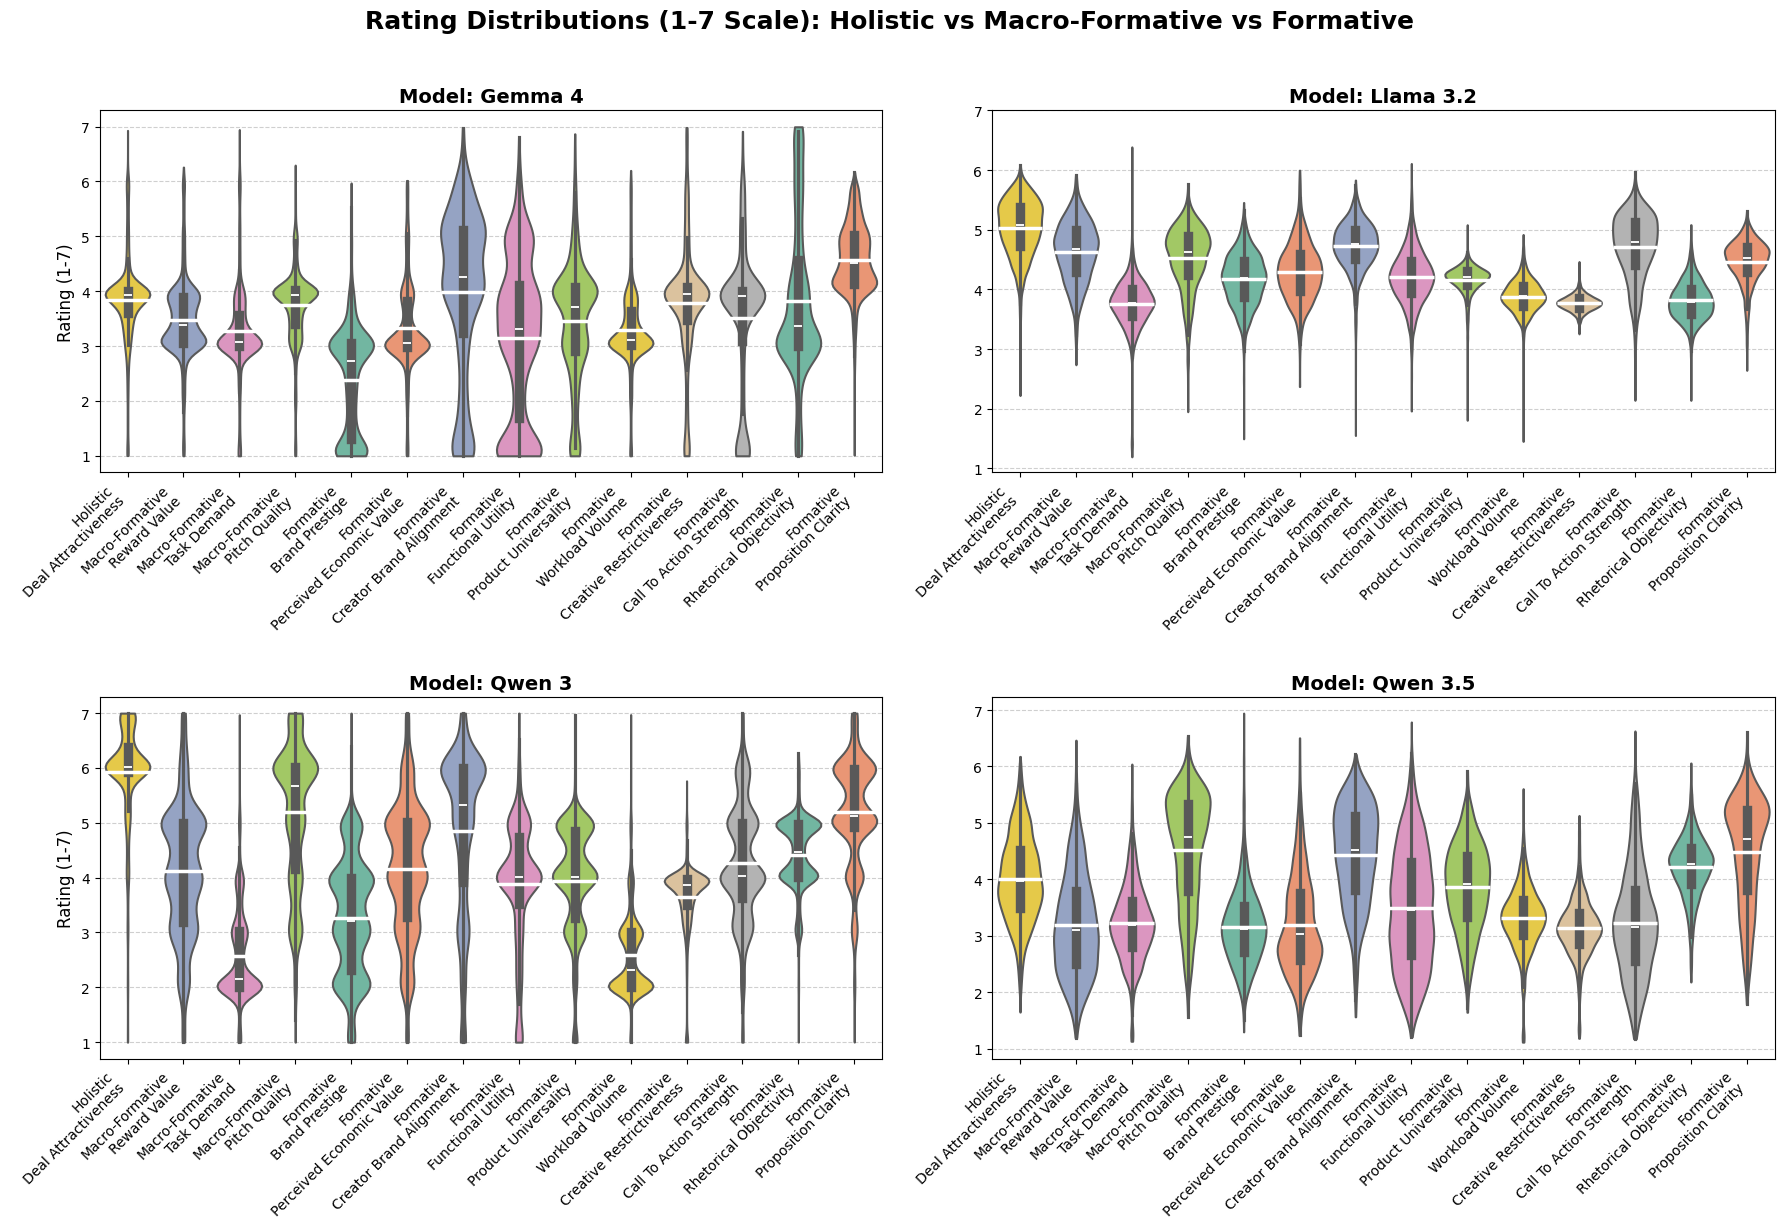

In [26]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

rating_range = (1, 7)
plot_rating_distributions_by_architecture(
    final_df, plot_order=plot_order, dim_map_clean=dim_map_clean, rating_range=rating_range)

## Verbosity bias (relationship between input length and rating)

In [27]:
from src.general_analysis.diagnostics import compute_verbosity_correlations
from src.general_analysis.visualisations import plot_formative_verbosity_breakdown
from src.general_analysis.visualisations import plot_verbosity_breakdown

### Ceiling effect/ effect per textual asset

We observe that there is a curve, characteristic for requirements and body word count. For the Gemma 4 and Qwen 3.5 we see that rating tends to increase until around 150 words, after which it flatlines. This is expected. When a text is very short, words can reliably increase the quality of a text since they add more information ("complex campaigns require sufficient token volume to define rules and reduce ambiguity"). At around 180 words, we see this initial 'verbosity reward' flatline, and even invert in some cases, where longer texts get penalized. This motivates our choice for computing the absolute Cohen's D over the lower and upper quartile. Cohen's D captures the change between two subsets of the data, controlling for the standard deviation. This last part is important, since the differences in how much of the scale each model uses is different. E.g., Llama has a very low standard deviation, and it moves up 0.8 points as word count increases. However, 0.8 is very large when the standard deviation is so low, leading to a large Cohen's D. 

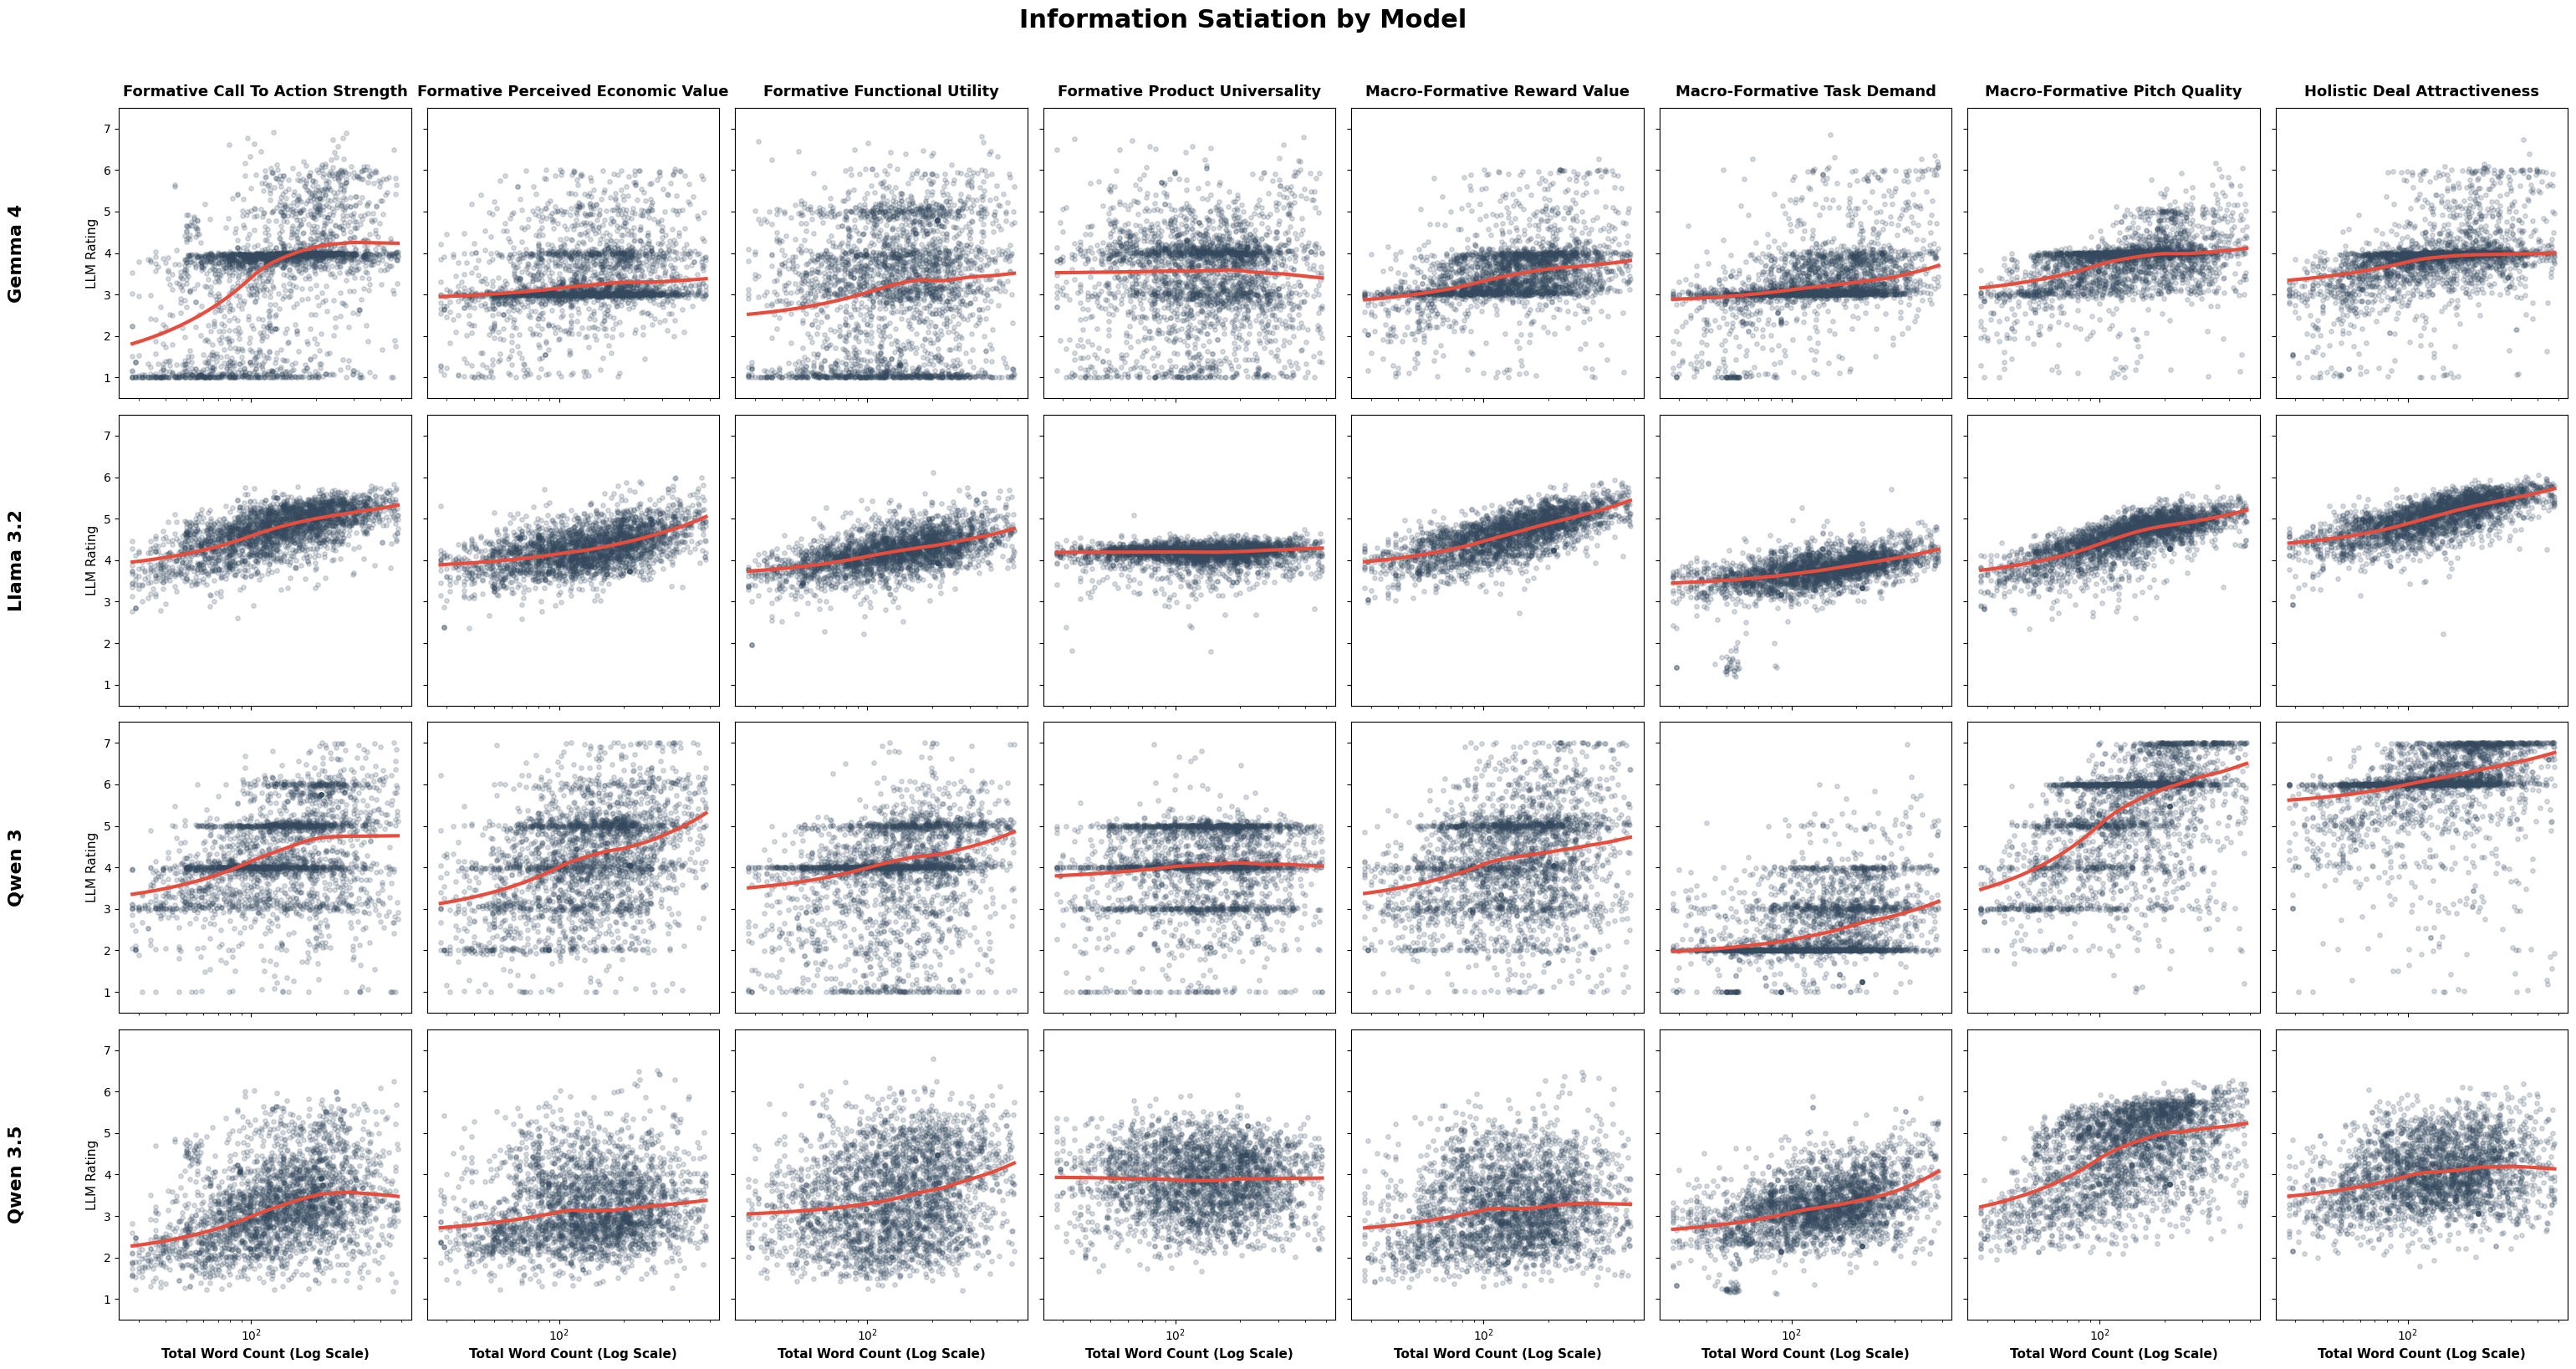

In [28]:
from src.general_analysis.visualisations import plot_verbosity_grid

models = final_df['model_name_clean'].unique()
dimensions = final_df['dimension_name_clean'].unique()[1:5]
dimensions = ['Formative\nCall To Action Strength',
              'Formative\nPerceived Economic Value',
              'Formative\nFunctional Utility',
              'Formative\nProduct Universality',
              'Macro-Formative\nReward Value',
              'Macro-Formative\nTask Demand',
              'Macro-Formative\nPitch Quality',
              'Holistic\nDeal Attractiveness'
              ]
plot_verbosity_grid(final_df, models=models, dimensions=dimensions, model_col='model_name_clean',
                    dim_col='dimension_name_clean',
                    x_col='raw_input_word_count',
                    y_col='mean_rating')

C:\Users\Wouter Barter\Documents\AI_thesis\src\general_analysis\visualisations.py:334: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=res_df, x='Text Section', y='Absolute Cohen\'s d', hue='Model',


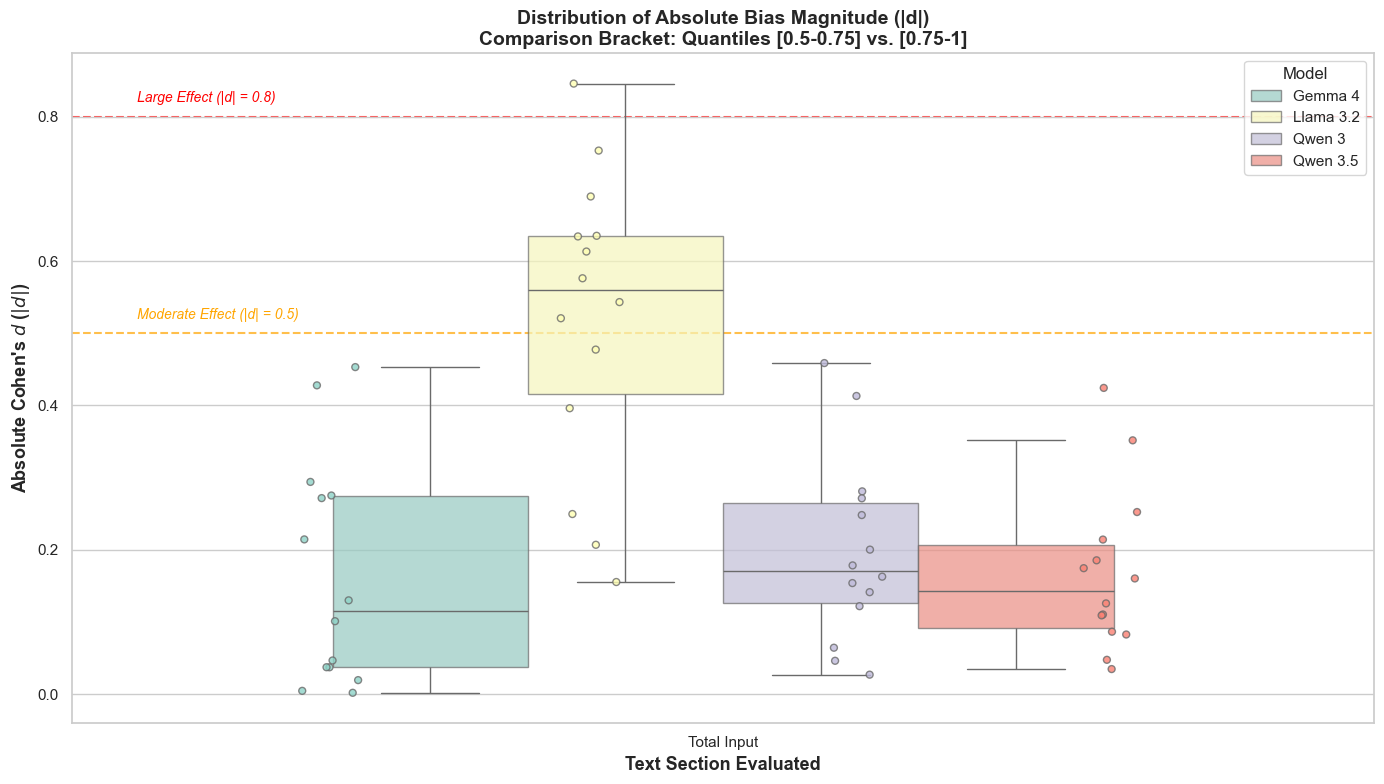

In [29]:
from src.general_analysis.visualisations import plot_absolute_bias_spread

sections = {
    'Total Input': 'raw_input_word_count'}

res_df_upperquart = plot_absolute_bias_spread(final_df, sections, p_lower=[
    0.5, 0.75], p_upper=[0.75, 1])


# sections = {
#     'Total Input': 'raw_input_word_count',
#     'Deal Text (Body)': 'text_word_count',
#     'Requirements': 'requirements_word_count'
# }
# res_df = plot_absolute_bias_spread(final_df, sections, p_lower=[
#                                    0, 0.25], p_upper=[0.75, 1])

Isolating True Verbosity Bias via Mature Text Bracketing
*"In evaluating LLM length heuristics, it is critical to distinguish between 'construct-relevant verbosity' (the necessary resolution of information deficits) and 'heuristic verbosity bias' (the blind rewarding of token volume). Because dimensions such as 'Task Demand' and 'Proposition Clarity' inherently require textual specification, rating increases between short (Q1) and moderate (Q3) texts represent accurate semantic evaluation, not bias.

Therefore, to measure true construct-irrelevant verbosity bias, we isolated our final effect size calculations to the mature text bracket (Q3 vs. Q4). By evaluating texts that have already structurally satisfied the rubric, we test whether the model correctly flatlines its evaluation, or whether a residual length heuristic remains active."*

## Entropy

### Distribution

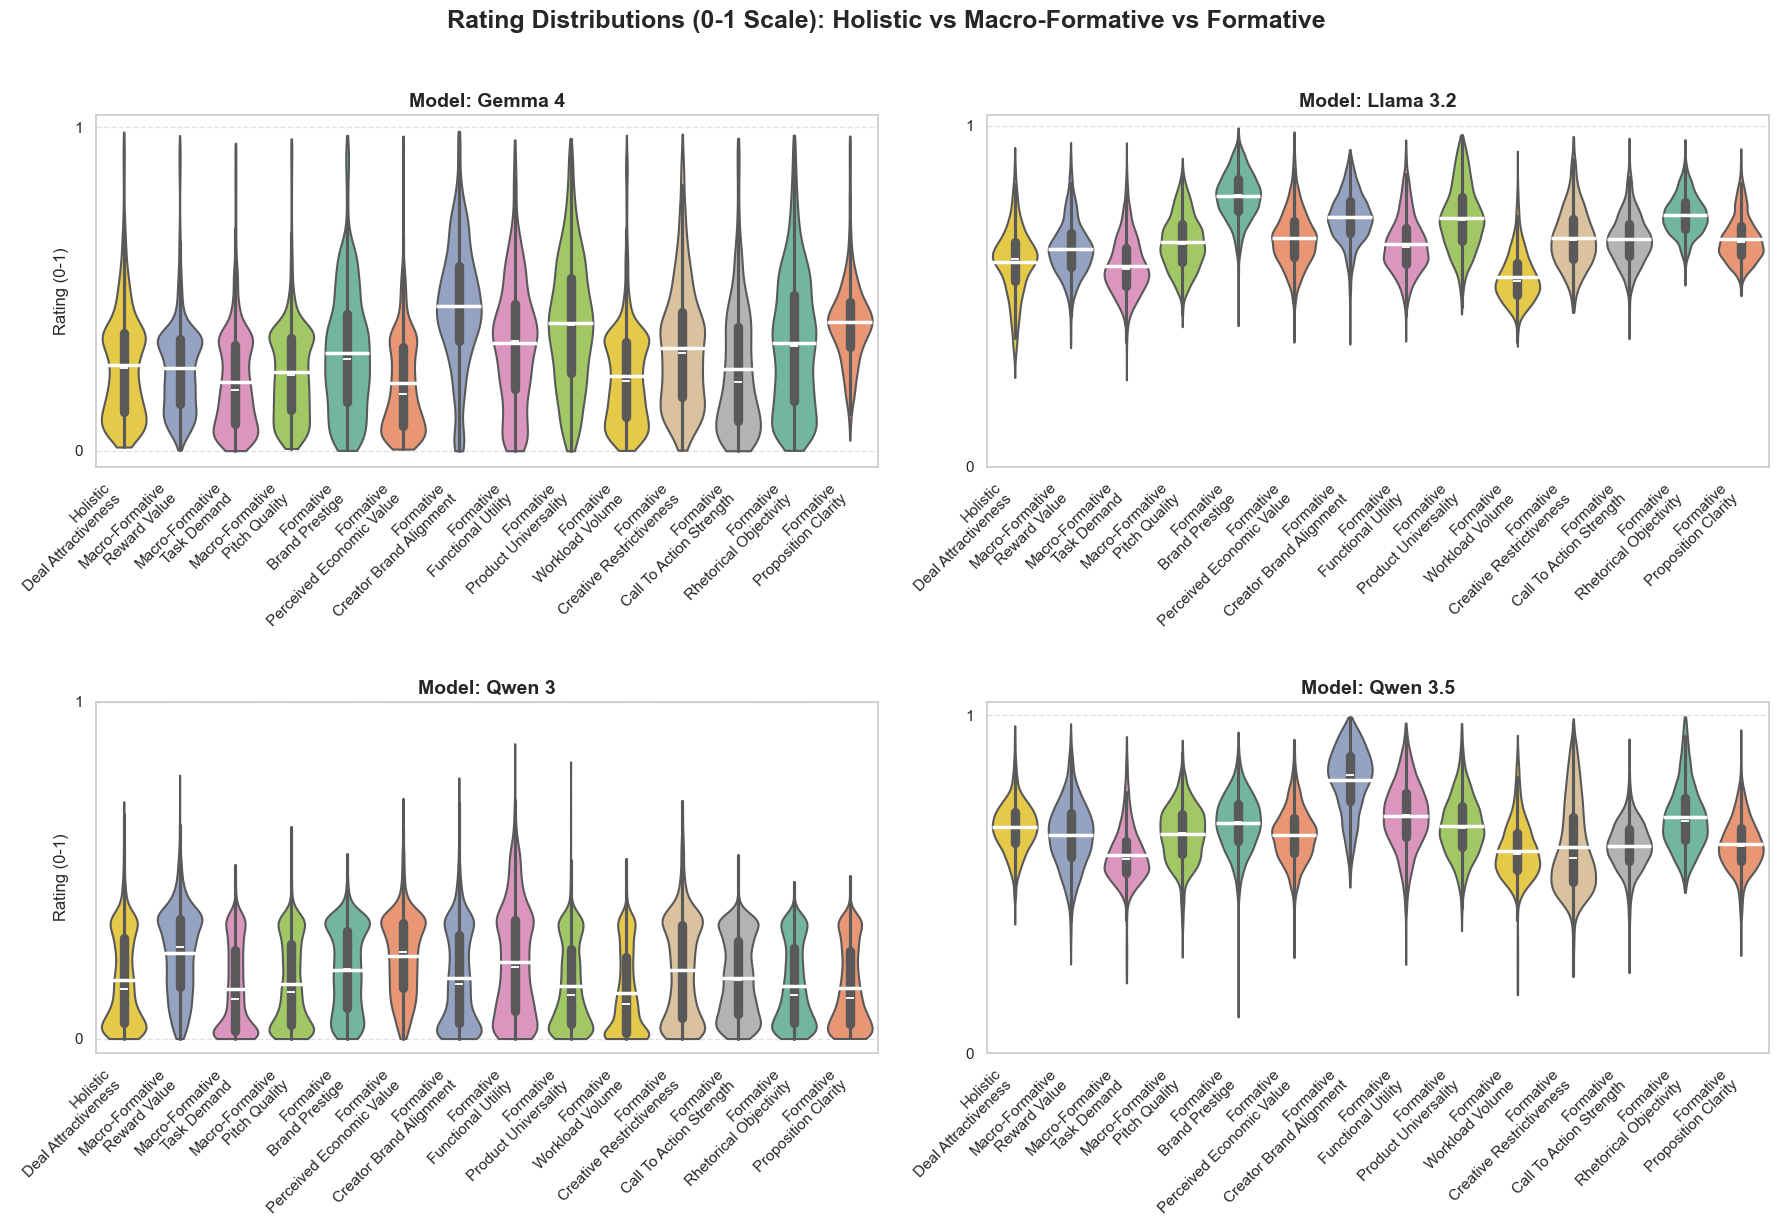

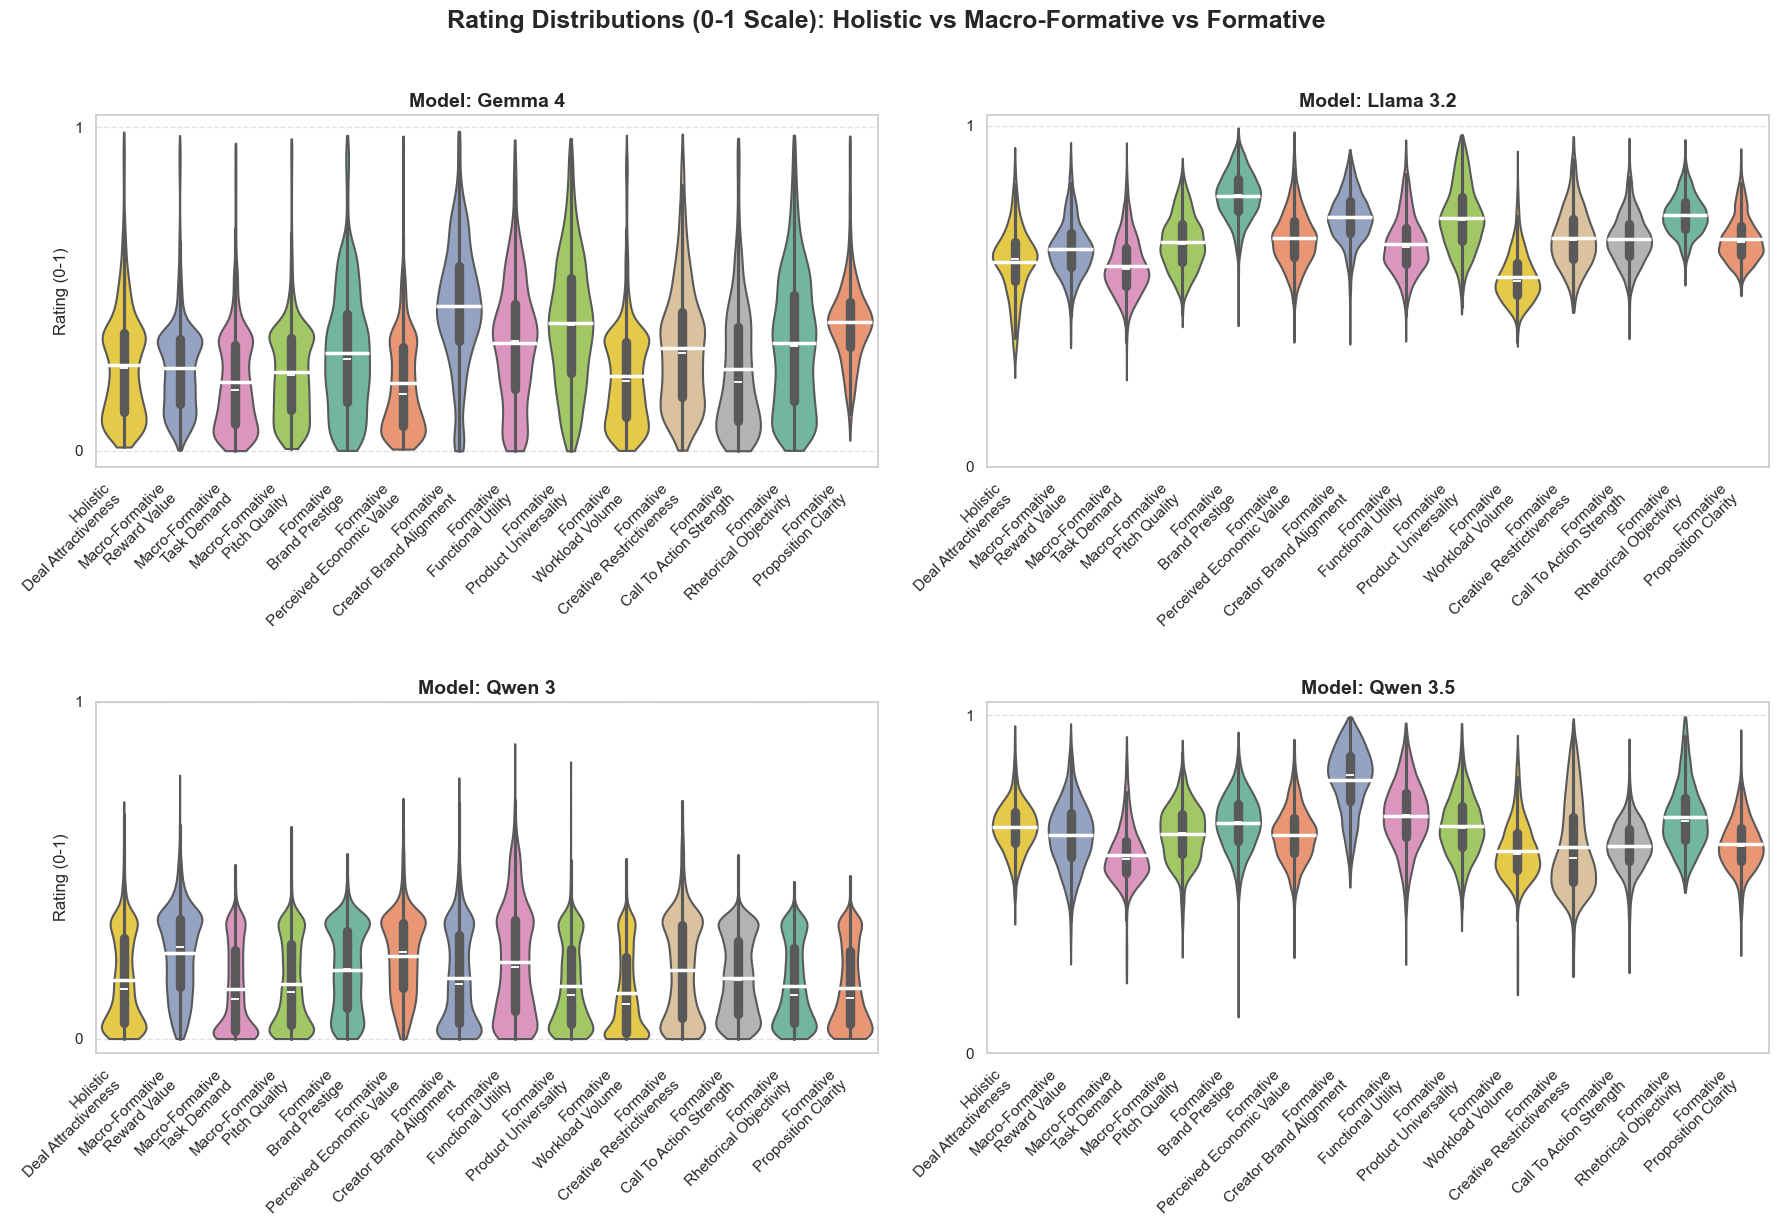

In [30]:
from src.general_analysis.visualisations import plot_rating_distributions_by_architecture

rating_range = (0, 1)
plot_rating_distributions_by_architecture(
    final_df, plot_order=plot_order, score_col='normalized_entropy', rating_range=(0, 1), dim_map_clean=dim_map_clean)

## Correlation between predictors and target

In [31]:
import pandas as pd
import numpy as np
import scipy.stats as stats


def compute_dimension_validity(
    df: pd.DataFrame,
    value_col: str = 'mean_rating',
    target_col: str = 'apps_after_7_days'
) -> pd.DataFrame:
    """
    Computes isolated Spearman rank correlations between individual psychometric 
    dimensions and the behavioral KPI across all model-prompt specifications.
    """
    results = []
    grouped = df.groupby(['model_name', 'prompt_name', 'dimension_name'])

    for (model, prompt, dim), group in grouped:
        # Enforce strict pairwise deletion for valid correlation bounds
        valid_data = group.dropna(subset=[value_col, target_col])

        if len(valid_data) > 1:
            rho, p_val = stats.spearmanr(
                valid_data[value_col], valid_data[target_col])
            n_obs = len(valid_data)
        else:
            rho, p_val, n_obs = np.nan, np.nan, 0

        results.append({
            'model_name': model,
            'prompt_name': prompt,
            'dimension_name': dim,
            'spearman_rho': rho,
            'p_value': p_val,
            'n_obs': n_obs
        })

    return pd.DataFrame(results).sort_values(by='spearman_rho', ascending=False).reset_index(drop=True)


# Execution
dimension_validity_df = compute_dimension_validity(final_df)
print(dimension_validity_df.head(15))

                          model_name      prompt_name  \
0                    Qwen/Qwen3.5-4B        Formative   
1        Qwen/Qwen3-4B-Instruct-2507        Formative   
2              google/gemma-4-E2B-it        Formative   
3                    Qwen/Qwen3.5-4B        Formative   
4        Qwen/Qwen3-4B-Instruct-2507        Formative   
5        Qwen/Qwen3-4B-Instruct-2507  Macro-Formative   
6              google/gemma-4-E2B-it        Formative   
7   meta-llama/Llama-3.2-3B-Instruct        Formative   
8                    Qwen/Qwen3.5-4B        Formative   
9                    Qwen/Qwen3.5-4B   Holistic Naive   
10       Qwen/Qwen3-4B-Instruct-2507        Formative   
11       Qwen/Qwen3-4B-Instruct-2507   Holistic Naive   
12             google/gemma-4-E2B-it        Formative   
13                   Qwen/Qwen3.5-4B        Formative   
14                   Qwen/Qwen3.5-4B  Macro-Formative   

                            dimension_name  spearman_rho       p_value  n_obs  
0      

# Main Analysis: Regression

In [19]:
CONTENT_TYPE_COL = 'macro_category'
CATEGORICALS = ['market_scope', CONTENT_TYPE_COL,
                'year_month', 'platform_strategy', 'requirements_length_bucket', 'body_length_bucket']

CONTINUOUS = ['competitor_density']
BINARIES = ['strict_follower_requirement']

EXPERIMENTAL_GROUPS = ['model_name_clean', 'prompt_name']

## Mean

In [20]:
runner_mean = create_regression_runner(
    target_col='apps_after_7_days',  # Log-transformed target
    # target_col='log_apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin',
)

runner_mean.run_baseline_model(
    df=og_df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline"
)

predictor_names = ['z_mean_rating']

runner_mean.run_regression(df=final_df,
                           cat_vars=CATEGORICALS,
                           bin_vars=BINARIES,
                           num_vars=CONTINUOUS,
                           predictor_names=predictor_names)

✓ Baseline model fitted: 2960 observations, AIC=21056.41


In [21]:
from src.general_analysis.diagnostics import collect_all_diagnostics, overview

runner_mean_summ = runner_mean.summarize().copy()

interactive_regression_results_selector(runner_mean.results)

Dropdown(description='Select option:', index=7, layout=Layout(width='400px'), options=('baseline', 'Gemma 4 Fo…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2960
Model:               NegativeBinomial   Df Residuals:                     2912
Method:                           MLE   Df Model:                           47
Date:                Wed, 01 Jul 2026   Pseudo R-squ.:                 0.07176
Time:                        20:56:01   Log-Likelihood:                -10312.
converged:                       True   LL-Null:                       -11109.
Covariance Type:              cluster   LLR p-value:                2.230e-303
=====================================================================================================================
                                                        coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------
const                                                 2.4913      0.189     13.155      0.000       2.120       2.863
deal_pitch_brand_prestige_z_mean_rating               0.0347      0.030      1.172      0.241      -0.023       0.093
deal_pitch_call_to_action_strength_z_mean_rating     -0.0371      0.035     -1.062      0.288      -0.106       0.031
deal_pitch_creative_restrictiveness_z_mean_rating    -0.0480      0.029     -1.630      0.103      -0.106       0.010
deal_pitch_creator_brand_alignment_z_mean_rating     -0.0154      0.038     -0.412      0.681      -0.089       0.058
deal_pitch_functional_utility_z_mean_rating          -0.1330      0.029     -4.521      0.000      -0.191      -0.075
deal_pitch_perceived_economic_value_z_mean_rating     0.2512      0.030      8.307      0.000       0.192       0.311
deal_pitch_product_universality_z_mean_rating         0.2877      0.028     10.214      0.000       0.232       0.343
deal_pitch_proposition_clarity_z_mean_rating          0.0073      0.035      0.212      0.832      -0.061       0.075
deal_pitch_rhetorical_objectivity_z_mean_rating      -0.0787      0.028     -2.854      0.004      -0.133      -0.025
deal_pitch_workload_volume_z_mean_rating              0.0002      0.030      0.007      0.994      -0.058       0.058
strict_follower_requirement                          -0.2225      0.055     -4.025      0.000      -0.331      -0.114
competitor_density                                   -0.0314      0.007     -4.268      0.000      -0.046      -0.017
market_scope_Tier1_NonNLD_international              -1.2147      0.223     -5.457      0.000      -1.651      -0.778
market_scope_Tier2_NLD_only                          -0.3144      0.059     -5.287      0.000      -0.431      -0.198
market_scope_Tier3_BEL_Only                          -1.1391      0.157     -7.276      0.000      -1.446      -0.832
market_scope_Tier4_Germany                           -1.6780      0.077    -21.788      0.000      -1.829      -1.527
market_scope_Tier5_Other                             -1.4364      0.163     -8.803      0.000      -1.757      -1.116
macro_category_Beauty                                 0.4993      0.166      3.008      0.003       0.174       0.825
macro_category_Digital Entertainment                 -0.0358      0.173     -0.207      0.836      -0.375       0.303
macro_category_Dining & Hospitality                   0.1836      0.173      1.061      0.289      -0.156       0.523
macro_category_Family & Parenting                    -0.0320      0.192     -0.167      0.868      -0.408       0.345
macro_category_Fashion                                0.3996      0.177      2.255      0.024       0.052       0.747
macro_category_Home Cooking & CPG                     0.2666      0.164      1.628      0.104      -0.055       0.588
macro_category_In-Person Experiences                 -0

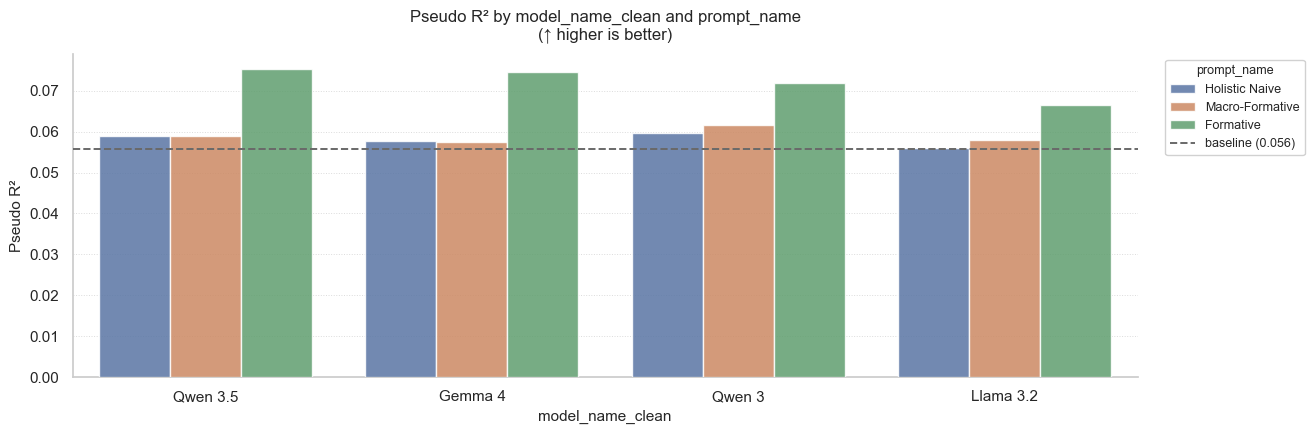

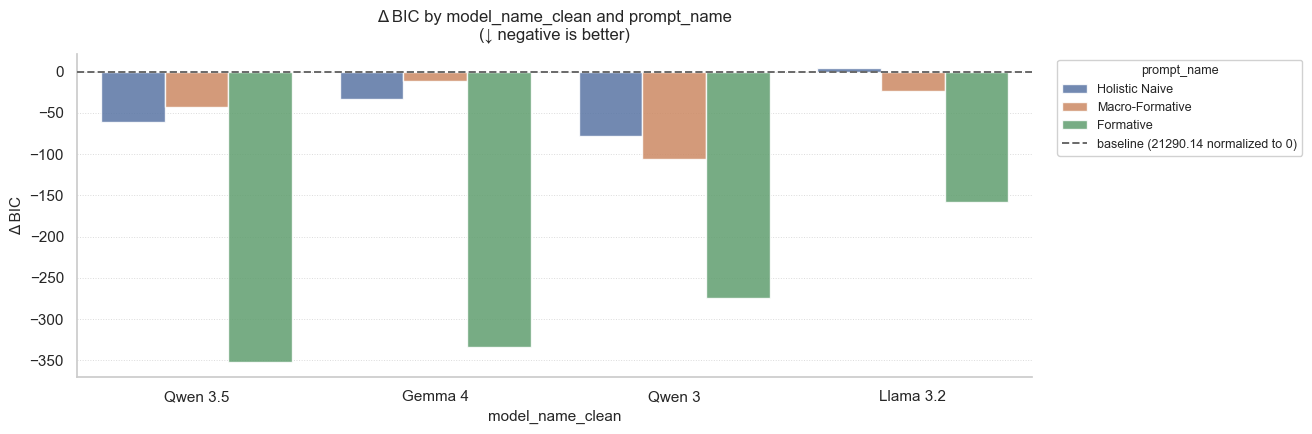

In [35]:
from src.general_analysis.visualisations import plot_metric_bars

plt_r2 = plot_metric_bars(runner=runner_mean,
                          metric='pseudo_r_squared',
                          model_col='model_name_clean',
                          prompt_col='prompt_name', plot_order=prompt_order,
                          plot_delta=False)


plt_bic = plot_metric_bars(runner=runner_mean,
                           metric='bic',
                           model_col='model_name_clean',
                           prompt_col='prompt_name', plot_order=prompt_order,
                           plot_delta=True)

In [36]:
# same API as FeedbackQA runner
runner_mean_summ = runner_mean.summarize().copy()

runner_mean_summ

,model_name_clean,prompt_name,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,condition_number,mse,mae,pearson_r,spearman_rho,kendall_tau
10,Qwen 3.5,Formative,Qwen 3.5 Formative,2960,NaN,NaN,0.075278,20644.100860,20937.755143,-10273.050430,NaN,326.188368,10.624192,0.521872,0.637756,0.462468
1,Gemma 4,Formative,Gemma 4 Formative,2960,NaN,NaN,0.074461,20662.256387,20955.910669,-10282.128193,NaN,331.608345,10.707070,0.510475,0.634311,0.460098
7,Qwen 3,Formative,Qwen 3 Formative,2960,NaN,NaN,0.071760,20722.267302,21015.921585,-10312.133651,NaN,329.743108,10.720511,0.512808,0.631668,0.457137
4,Llama 3.2,Formative,Llama 3.2 Formative,2960,NaN,NaN,0.066509,20838.936248,21132.590531,-10370.468124,NaN,340.487888,10.915302,0.490147,0.612381,0.441054
9,Qwen 3,Macro-Formative,Qwen 3 Macro-Formative,2960,NaN,NaN,0.061650,20932.895642,21184.599313,-10424.447821,NaN,351.094581,11.178584,0.465055,0.592919,0.424302
8,Qwen 3,Holistic Naive,Qwen 3 Holistic Naive,2960,NaN,NaN,0.059694,20972.356936,21212.074718,-10446.178468,NaN,351.583029,11.198505,0.462819,0.586819,0.419512
11,Qwen 3.5,Holistic Naive,Qwen 3.5 Holistic Naive,2960,NaN,NaN,0.058930,20989.328384,21229.046165,-10454.664192,NaN,350.831707,11.206557,0.464561,0.583632,0.416906
12,Qwen 3.5,Macro-Formative,Qwen 3.5 Macro-Formative,2960,NaN,NaN,0.058851,20995.088369,21246.792040,-10455.544185,NaN,348.255218,11.162792,0.470421,0.583326,0.417202
6,Llama 3.2,Macro-Formative,Llama 3.2 Macro-Formative,2960,NaN,NaN,0.057934,21015.455019,21267.158690,-10465.727509,NaN,349.977491,11.202585,0.466542,0.580192,0.414792
2,Gemma 4,Holistic Naive,Gemma 4 Holistic Naive,2960,NaN,NaN,0.057658,21017.595780,21257.313562,-10468.797890,NaN,354.724187,11.289688,0.455262,0.578136,0.412189


### Extract results for the appendix

In [ ]:
import re
import numpy as np
import pandas as pd


def _as_series(x, index):
    """Convert statsmodels arrays/Series to a pandas Series with the right index."""
    if isinstance(x, pd.Series):
        return x
    return pd.Series(np.asarray(x), index=index)


def significance_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    if p < 0.10:
        return "†"
    return ""


def extract_nb_results(
    result,
    model_name=None,
    include_regex=None,
    exclude_regex=None,
    drop_intercept=True,
    drop_alpha=True,
    round_digits=3,
):
    """
    Extract coefficients and model metrics from a statsmodels NegativeBinomialResultsWrapper.

    Parameters
    ----------
    result:
        statsmodels NegativeBinomialResultsWrapper.
    model_name:
        Optional model label, e.g. "Qwen 3.5 Formative".
    include_regex:
        Optional regex. Only predictors matching this pattern are retained.
        Useful for selecting only LLM criterion predictors.
    exclude_regex:
        Optional regex. Predictors matching this pattern are removed.
        Useful for excluding controls, fixed effects, or dummies.
    drop_intercept:
        Whether to remove intercept/constant terms.
    drop_alpha:
        Whether to remove the NB dispersion parameter alpha from the coefficient table.
    round_digits:
        Number of decimals for rounded display columns.

    Returns
    -------
    coef_df:
        DataFrame with beta, SE, z, p, IRR, confidence intervals, and formatted columns.
    metrics:
        Series with nobs, log-likelihood, AIC, BIC, pseudo-R2, alpha, etc.
    """

    # --- coefficients ---
    params = result.params
    if not isinstance(params, pd.Series):
        names = getattr(result.model, "exog_names", None)
        if names is None:
            names = [f"x{i}" for i in range(len(params))]
        params = pd.Series(np.asarray(params), index=names)

    idx = params.index
    bse = _as_series(result.bse, idx)
    pvalues = _as_series(result.pvalues, idx)

    # z-values are usually available, but compute them if needed
    try:
        zvalues = _as_series(result.tvalues, idx)
    except Exception:
        zvalues = params / bse

    conf = result.conf_int()
    if isinstance(conf, np.ndarray):
        conf = pd.DataFrame(conf, index=idx, columns=["ci_low", "ci_high"])
    else:
        conf = conf.copy()
        conf.columns = ["ci_low", "ci_high"]

    coef_df = pd.DataFrame({
        "model": model_name,
        "predictor": idx,
        "beta": params.values,
        "se": bse.values,
        "z": zvalues.values,
        "p": pvalues.values,
        "ci_low": conf["ci_low"].values,
        "ci_high": conf["ci_high"].values,
    })

    # Drop intercept / alpha if requested
    if drop_intercept:
        coef_df = coef_df[~coef_df["predictor"].str.lower().isin(
            ["const", "intercept"]
        )]

    if drop_alpha:
        coef_df = coef_df[coef_df["predictor"].str.lower() != "alpha"]

    # Include / exclude filters
    if include_regex is not None:
        coef_df = coef_df[coef_df["predictor"].str.contains(
            include_regex, regex=True, case=False, na=False
        )]

    if exclude_regex is not None:
        coef_df = coef_df[~coef_df["predictor"].str.contains(
            exclude_regex, regex=True, case=False, na=False
        )]

    # IRR and CI on multiplicative scale
    coef_df["irr"] = np.exp(coef_df["beta"])
    coef_df["irr_ci_low"] = np.exp(coef_df["ci_low"])
    coef_df["irr_ci_high"] = np.exp(coef_df["ci_high"])
    coef_df["stars"] = coef_df["p"].apply(significance_stars)

    # Formatted columns for LaTeX/reporting
    r = round_digits
    coef_df["beta_se"] = (
        coef_df["beta"].round(r).astype(str)
        + coef_df["stars"]
        + " ("
        + coef_df["se"].round(r).astype(str)
        + ")"
    )
    coef_df["irr_fmt"] = coef_df["irr"].round(r).astype(str)
    coef_df["p_fmt"] = coef_df["p"].map(lambda x: f"{x:.3f}")

    # --- model metrics ---
    llf = getattr(result, "llf", np.nan)
    llnull = getattr(result, "llnull", np.nan)

    if hasattr(result, "prsquared"):
        pseudo_r2 = result.prsquared
    elif np.isfinite(llf) and np.isfinite(llnull) and llnull != 0:
        pseudo_r2 = 1 - (llf / llnull)
    else:
        pseudo_r2 = np.nan

    # NB alpha is sometimes in params
    alpha = np.nan
    for name in params.index:
        if str(name).lower() == "alpha":
            alpha = params.loc[name]
            break

    metrics = pd.Series({
        "model": model_name,
        "nobs": getattr(result, "nobs", np.nan),
        "df_model": getattr(result, "df_model", np.nan),
        "df_resid": getattr(result, "df_resid", np.nan),
        "llf": llf,
        "llnull": llnull,
        "pseudo_r2": pseudo_r2,
        "aic": getattr(result, "aic", np.nan),
        "bic": getattr(result, "bic", np.nan),
        "alpha": alpha,
    })

    return coef_df.reset_index(drop=True), metrics


def latex_escape(s):
    """Escape LaTeX special characters in labels."""
    replacements = {
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
    }
    for old, new in replacements.items():
        s = s.replace(old, new)
    return s


def extract_multiple_nb_results(
    results_dict,
    model_names,
    include_regex=None,
    exclude_regex=None,
    drop_intercept=True,
    drop_alpha=True,
    round_digits=3,
):
    """
    Extract coefficients and metrics for several named models from a results dictionary.
    """
    coef_tables = []
    metric_rows = []

    for name in model_names:
        coef_df, metrics = extract_nb_results(
            results_dict[name],
            model_name=name,
            include_regex=include_regex,
            exclude_regex=exclude_regex,
            drop_intercept=drop_intercept,
            drop_alpha=drop_alpha,
            round_digits=round_digits,
        )
        coef_tables.append(coef_df)
        metric_rows.append(metrics)

    all_coefs = pd.concat(coef_tables, ignore_index=True)
    all_metrics = pd.DataFrame(metric_rows)

    return all_coefs, all_metrics


def clean_baseline_label(var):
    """Human-readable labels for Barter baseline predictors."""

    explicit = {
        "strict_follower_requirement": "Strict follower requirement",
        "competitor_density": "Competitor density",

        "market_scope_Tier1_NonNLD_international": "Market scope: non-Dutch international",
        "market_scope_Tier2_NLD_only": "Market scope: Netherlands only",
        "market_scope_Tier3_BEL_Only": "Market scope: Belgium only",
        "market_scope_Tier4_Germany": "Market scope: Germany",
        "market_scope_Tier5_Other": "Market scope: other",

        "platform_strategy_IG_and_TikTok": "Platform strategy: Instagram and TikTok",
        "platform_strategy_Instagram_Only": "Platform strategy: Instagram only",
        "platform_strategy_TikTok_Only": "Platform strategy: TikTok only",
        "platform_strategy_Unspecified": "Platform strategy: unspecified",

        "requirements_length_bucket_2. Medium-Short": "Requirements length: medium-short",
        "requirements_length_bucket_3. Medium-Long": "Requirements length: medium-long",
        "requirements_length_bucket_4. Long": "Requirements length: long",

        "body_length_bucket_2. Medium-Short": "Body length: medium-short",
        "body_length_bucket_3. Medium-Long": "Body length: medium-long",
        "body_length_bucket_4. Long": "Body length: long",
    }

    if var in explicit:
        return explicit[var]

    if var.startswith("macro_category_"):
        category = var.replace("macro_category_", "")
        return f"Product category: {category}"

    if var.startswith("year_month_"):
        ym = var.replace("year_month_", "")
        return f"Month-year: {ym}"

    return var.replace("_", " ").title()


def baseline_group(var):
    """Group predictors for display order in the LaTeX table."""
    if var in ["strict_follower_requirement", "competitor_density"]:
        return "Deal and market controls"
    if var.startswith("market_scope_"):
        return "Market scope"
    if var.startswith("macro_category_"):
        return "Product category"
    if var.startswith("platform_strategy_"):
        return "Platform strategy"
    if var.startswith("requirements_length_bucket_"):
        return "Requirements length"
    if var.startswith("body_length_bucket_"):
        return "Body length"
    if var.startswith("year_month_"):
        return "Month-year fixed effects"
    return "Other"


def extract_baseline_coefficients(
    result,
    include_const=False,
    include_alpha=False,
    include_year_month=False,
    round_digits=3,
):
    """
    Extract clean baseline coefficients from a statsmodels NegativeBinomial result.

    Returns a DataFrame with beta, SE, p, IRR, and display labels.
    """

    params = result.params
    if not isinstance(params, pd.Series):
        names = getattr(result.model, "exog_names", None)
        params = pd.Series(np.asarray(params), index=names)

    bse = result.bse if isinstance(result.bse, pd.Series) else pd.Series(
        result.bse, index=params.index)
    pvalues = result.pvalues if isinstance(
        result.pvalues, pd.Series) else pd.Series(result.pvalues, index=params.index)

    rows = []
    for var in params.index:
        if var == "const" and not include_const:
            continue
        if var == "alpha" and not include_alpha:
            continue
        if var.startswith("year_month_") and not include_year_month:
            continue

        beta = params[var]
        se = bse[var]
        p = pvalues[var]
        irr = np.exp(beta)

        rows.append({
            "raw_predictor": var,
            "group": baseline_group(var),
            "predictor": clean_baseline_label(var),
            "beta": beta,
            "se": se,
            "p": p,
            "irr": irr,
            "stars": significance_stars(p),
        })

    df = pd.DataFrame(rows)

    group_order = {
        "Deal and market controls": 1,
        "Market scope": 2,
        "Product category": 3,
        "Platform strategy": 4,
        "Requirements length": 5,
        "Body length": 6,
        "Month-year fixed effects": 7,
        "Other": 99,
    }

    df["group_order"] = df["group"].map(group_order).fillna(99)
    df = df.sort_values(["group_order", "raw_predictor"]
                        ).reset_index(drop=True)

    r = round_digits
    df["beta_fmt"] = df.apply(
        lambda x: f"${x['beta']:.{r}f}{x['stars']}$",
        axis=1
    )
    df["se_fmt"] = df["se"].map(lambda x: f"$({x:.{r}f})$")
    df["irr_fmt"] = df["irr"].map(lambda x: f"{x:.{r}f}")
    df["p_fmt"] = df["p"].map(lambda x: f"{x:.3f}")

    return df


def baseline_coefficients_to_latex(
    df,
    caption="Structural Baseline Coefficient Estimates for Barter Deals",
    label="tab:barter_baseline_coefficients",
    include_group_headers=True,
):
    """
    Produce a clean booktabs LaTeX table with coefficient rows and SE rows.
    """

    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"\centering")
    lines.append(r"\small")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\begin{tabular}{lcc}")
    lines.append(r"\toprule")
    lines.append(r"Predictor & $\beta$ & IRR \\")
    lines.append(r"\midrule")

    current_group = None

    for _, row in df.iterrows():
        group = row["group"]

        if include_group_headers and group != current_group:
            if current_group is not None:
                lines.append(r"\addlinespace[0.35em]")
            lines.append(
                rf"\multicolumn{{3}}{{l}}{{\textit{{{latex_escape(group)}}}}} \\")
            current_group = group

        predictor = latex_escape(row["predictor"])
        lines.append(rf"{predictor} & {row['beta_fmt']} & {row['irr_fmt']} \\")
        lines.append(rf" & {row['se_fmt']} &  \\")

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}")
    lines.append("")
    lines.append(r"\begin{flushleft}")
    lines.append(r"\footnotesize")
    lines.append(
        r"\textit{Note.} Coefficients are from the structural baseline Negative Binomial regression with log link. "
        r"The model includes only non-LLM platform covariates and month-year fixed effects. "
        r"Month-year fixed effects are included but omitted from the table. "
        r"IRR denotes the incidence-rate ratio, $\exp(\beta)$, which expresses the coefficient on the expected-count scale: "
        r"values above 1 indicate higher expected application counts, while values below 1 indicate lower expected application counts, conditional on the other controls. "
        r"Standard errors, reported in parentheses, are clustered at the partner level. "
        r"Significance levels: $^{\dagger}p < .10$, $^{*}p < .05$, $^{**}p < .01$, $^{***}p < .001$."
    )
    lines.append(r"\end{flushleft}")
    lines.append(r"\end{table}")

    return "\n".join(lines)

In [101]:
baseline_res = runner_mean.results["baseline"]

baseline_df = extract_baseline_coefficients(
    baseline_res,
    include_const=False,
    include_alpha=False,
    include_year_month=False,
    round_digits=3,
)

latex_table = baseline_coefficients_to_latex(baseline_df)

print(latex_table)

\begin{table}[htbp]
\centering
\small
\caption{Structural Baseline Coefficient Estimates for Barter Deals}
\label{tab:barter_baseline_coefficients}
\begin{tabular}{lcc}
\toprule
Predictor & $\beta$ & IRR \\
\midrule
\multicolumn{3}{l}{\textit{Deal and market controls}} \\
Competitor density & $-0.042***$ & 0.959 \\
 & $(0.008)$ &  \\
Strict follower requirement & $-0.172**$ & 0.842 \\
 & $(0.060)$ &  \\
\addlinespace[0.35em]
\multicolumn{3}{l}{\textit{Market scope}} \\
Market scope: non-Dutch international & $-1.325***$ & 0.266 \\
 & $(0.245)$ &  \\
Market scope: Netherlands only & $-0.392***$ & 0.676 \\
 & $(0.066)$ &  \\
Market scope: Belgium only & $-1.295***$ & 0.274 \\
 & $(0.185)$ &  \\
Market scope: Germany & $-1.810***$ & 0.164 \\
 & $(0.084)$ &  \\
Market scope: other & $-1.434***$ & 0.238 \\
 & $(0.156)$ &  \\
\addlinespace[0.35em]
\multicolumn{3}{l}{\textit{Product category}} \\
Product category: Beauty & $0.602**$ & 1.826 \\
 & $(0.191)$ &  \\
Product category: Digital Ente

In [88]:
models = ["Gemma 4 Formative", "Qwen 3.5 Formative"]

coefs, metrics = extract_multiple_nb_results(
    runner_mean.results,
    model_names=models,
    include_regex=('deal_pitch')
)

coefs_subset = coefs[[
    "model", "predictor", "beta", "se", "p", "irr", "beta_se", "irr_fmt"
]]

coefs

,model,predictor,beta,se,z,p,ci_low,ci_high,irr,irr_ci_low,irr_ci_high,stars,beta_se,irr_fmt,p_fmt
0,Gemma 4 Formative,deal_pitch_brand_prestige_z_mean_rating,0.076725,0.026937,2.848314,4.473015e-03,0.023874,0.129576,1.079745,1.024162,1.138346,**,0.077** (0.027),1.08,0.004
1,Gemma 4 Formative,deal_pitch_call_to_action_strength_z_mean_rating,0.040140,0.032334,1.241408,2.147068e-01,-0.023301,0.103581,1.040957,0.976969,1.109136,,0.04 (0.032),1.041,0.215
2,Gemma 4 Formative,deal_pitch_creative_restrictiveness_z_mean_rating,-0.019101,0.026650,-0.716735,4.736823e-01,-0.071389,0.033187,0.981080,0.931100,1.033744,,-0.019 (0.027),0.981,0.474
3,Gemma 4 Formative,deal_pitch_creator_brand_alignment_z_mean_rating,0.037580,0.031648,1.187429,2.353026e-01,-0.024514,0.099674,1.038295,0.975784,1.104810,,0.038 (0.032),1.038,0.235
4,Gemma 4 Formative,deal_pitch_functional_utility_z_mean_rating,-0.142369,0.028788,-4.945441,8.720214e-07,-0.198852,-0.085887,0.867301,0.819671,0.917698,***,-0.142*** (0.029),0.867,0.000
5,Gemma 4 Formative,deal_pitch_perceived_economic_value_z_mean_rating,0.171118,0.028150,6.078765,1.642534e-09,0.115887,0.226349,1.186631,1.122869,1.254014,***,0.171*** (0.028),1.187,0.000
6,Gemma 4 Formative,deal_pitch_product_universality_z_mean_rating,0.338374,0.032269,10.485960,1.227180e-24,0.275061,0.401687,1.402665,1.316611,1.494343,***,0.338*** (0.032),1.403,0.000
7,Gemma 4 Formative,deal_pitch_proposition_clarity_z_mean_rating,-0.019843,0.025643,-0.773824,4.391932e-01,-0.070155,0.030469,0.980352,0.932249,1.030938,,-0.02 (0.026),0.98,0.439
8,Gemma 4 Formative,deal_pitch_rhetorical_objectivity_z_mean_rating,-0.027762,0.029956,-0.926770,3.542394e-01,-0.086537,0.031012,0.972619,0.917102,1.031498,,-0.028 (0.03),0.973,0.354
9,Gemma 4 Formative,deal_pitch_workload_volume_z_mean_rating,-0.011047,0.029627,-0.372867,7.093158e-01,-0.069175,0.047081,0.989014,0.933163,1.048207,,-0.011 (0.03),0.989,0.709


In [91]:
appendix_table = (
    coefs_subset
    .pivot(index="predictor", columns="model", values=["beta_se", "irr_fmt"])
)

print(
    appendix_table.to_latex(
        index=True,
        escape=False,
        caption="Fine-Grained Formative Coefficient Estimates for Selected Barter Deals Specifications",
        label="tab:barter_coefficients_selected"
    )
)

\begin{table}
\caption{Fine-Grained Formative Coefficient Estimates for Selected Barter Deals Specifications}
\label{tab:barter_coefficients_selected}
\begin{tabular}{lllll}
\toprule
 & \multicolumn{2}{r}{beta_se} & \multicolumn{2}{r}{irr_fmt} \\
model & Gemma 4 Formative & Qwen 3.5 Formative & Gemma 4 Formative & Qwen 3.5 Formative \\
predictor &  &  &  &  \\
\midrule
deal_pitch_brand_prestige_z_mean_rating & 0.077** (0.027) & 0.0 (0.029) & 1.08 & 1.0 \\
deal_pitch_call_to_action_strength_z_mean_rating & 0.04 (0.032) & 0.051 (0.034) & 1.041 & 1.052 \\
deal_pitch_creative_restrictiveness_z_mean_rating & -0.019 (0.027) & -0.039 (0.031) & 0.981 & 0.962 \\
deal_pitch_creator_brand_alignment_z_mean_rating & 0.038 (0.032) & 0.03 (0.034) & 1.038 & 1.03 \\
deal_pitch_functional_utility_z_mean_rating & -0.142*** (0.029) & -0.064* (0.031) & 0.867 & 0.938 \\
deal_pitch_perceived_economic_value_z_mean_rating & 0.171*** (0.028) & 0.155*** (0.029) & 1.187 & 1.167 \\
deal_pitch_product_universality_

## Mode

In [37]:
runner_mode = create_regression_runner(
    target_col='apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

runner_mode.run_baseline_model(
    df=og_df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline"
)

predictor_names = ['z_mode_rating']

runner_mode.run_regression(df=final_df,
                           cat_vars=CATEGORICALS,
                           bin_vars=BINARIES,
                           num_vars=CONTINUOUS,
                           predictor_names=predictor_names)

✓ Baseline model fitted: 2960 observations, AIC=21056.41


In [38]:
final_df['diff_mean_mode'] = abs(
    final_df['mean_rating'] - final_df['mode_rating'])
final_df.groupby('analysis_group_full')['diff_mean_mode'].mean().head(10)

analysis_group_full
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_brand_prestige              0.154660
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_call_to_action_strength     0.140776
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_creative_restrictiveness    0.161032
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_creator_brand_alignment     0.132332
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_functional_utility          0.162648
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_perceived_economic_value    0.176051
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_product_universality        0.122333
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_proposition_clarity         0.117672
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_rhetorical_objectivity      0.123427
Qwen/Qwen3-4B-Instruct-2507_1e1ff82a28e2_deal_pitch_workload_volume             0.103282
Name: diff_mean_mode, dtype: float64

In [39]:
interactive_regression_results_selector(runner_mode.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', 'Gemma 4 Formative',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2960
Model:               NegativeBinomial   Df Residuals:                     2922
Method:                           MLE   Df Model:                           37
Date:                Wed, 01 Jul 2026   Pseudo R-squ.:                 0.05582
Time:                        17:40:27   Log-Likelihood:                -10489.
converged:                       True   LL-Null:                       -11109.
Covariance Type:              cluster   LLR p-value:                2.436e-236
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const                                          2.4103      0.223     10.810      0.000       1.973       2.848
strict_follower_requirement                   -0.1720      0.060     -2.862      0.004      -0.290      -0.054
competitor_density                            -0.0422      0.008     -5.507      0.000      -0.057      -0.027
market_scope_Tier1_NonNLD_international       -1.3251      0.245     -5.408      0.000      -1.806      -0.844
market_scope_Tier2_NLD_only                   -0.3917      0.066     -5.896      0.000      -0.522      -0.261
market_scope_Tier3_BEL_Only                   -1.2954      0.185     -7.000      0.000      -1.659      -0.932
market_scope_Tier4_Germany                    -1.8105      0.084    -21.532      0.000      -1.975      -1.646
market_scope_Tier5_Other                      -1.4341      0.156     -9.193      0.000      -1.740      -1.128
macro_category_Beauty                          0.6023      0.191      3.161      0.002       0.228       0.976
macro_category_Digital Entertainment          -0.0523      0.201     -0.260      0.795      -0.448       0.343
macro_category_Dining & Hospitality            0.2709      0.195      1.389      0.165      -0.112       0.654
macro_category_Family & Parenting             -0.1160      0.223     -0.520      0.603      -0.554       0.322
macro_category_Fashion                         0.5121      0.202      2.538      0.011       0.116       0.908
macro_category_Home Cooking & CPG              0.3528      0.187      1.884      0.060      -0.015       0.720
macro_category_In-Person Experiences          -0.3017      0.242     -1.247      0.213      -0.776       0.173
macro_category_Lifestyle & Home                0.5790      0.197      2.939      0.003       0.192       0.966
macro_category_Tech & Niche                   -0.2525      0.256     -0.987      0.324      -0.755       0.250
macro_category_Uncategorized                  -0.0591      0.261     -0.226      0.821      -0.572       0.454
year_month_2025-06                             0.2196      0.106      2.079      0.038       0.012       0.427
year_month_2025-07                             0.4204      0.105      3.989      0.000       0.214       0.627
year_month_2025-08                             0.1246      0.118      1.059      0.290      -0.106       0.356
year_month_2025-09                             0.2677      0.106      2.533      0.011       0.060       0.475
year_month_2025-10                             0.6554      0.112      5.846      0.000       0.435       0.875
year_month_2025-11                             0.5871      0.115      5.120      0.000       0.362       0.812
year_month_2025-12                             0.5832      0.172      3.394      0.001       0.246       0.920
year_month_2026-01                             0.4976      0.126      3.951      0.000       0.251       0.745
year_month_2026-02    

In [40]:
runner_mode.summarize()

,model_name_clean,prompt_name,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,condition_number,mse,mae,pearson_r,spearman_rho,kendall_tau
10,Qwen 3.5,Formative,Qwen 3.5 Formative,2960,NaN,NaN,0.073650,20680.273237,20973.927520,-10291.136618,NaN,329.111322,10.649984,0.516066,0.633848,0.459247
1,Gemma 4,Formative,Gemma 4 Formative,2960,NaN,NaN,0.071166,20735.463556,21029.117839,-10318.731778,NaN,335.803240,10.775497,0.500819,0.628989,0.454790
7,Qwen 3,Formative,Qwen 3 Formative,2960,NaN,NaN,0.070076,20759.684986,21053.339269,-10330.842493,NaN,335.039833,10.796255,0.501623,0.628288,0.454001
9,Qwen 3,Macro-Formative,Qwen 3 Macro-Formative,2960,NaN,NaN,0.061259,20941.572647,21193.276318,-10428.786324,NaN,351.780981,11.178775,0.463328,0.591913,0.423341
8,Qwen 3,Holistic Naive,Qwen 3 Holistic Naive,2960,NaN,NaN,0.059074,20986.134309,21225.852090,-10453.067154,NaN,353.012262,11.221720,0.459497,0.583785,0.417253
11,Qwen 3.5,Holistic Naive,Qwen 3.5 Holistic Naive,2960,NaN,NaN,0.058553,20997.702224,21237.420005,-10458.851112,NaN,351.305947,11.199388,0.463428,0.583247,0.416516
12,Qwen 3.5,Macro-Formative,Qwen 3.5 Macro-Formative,2960,NaN,NaN,0.058625,21000.093672,21251.797343,-10458.046836,NaN,348.497177,11.173239,0.469853,0.582280,0.416420
4,Llama 3.2,Formative,Llama 3.2 Formative,2960,NaN,NaN,0.058374,21019.666803,21313.321086,-10460.833401,NaN,349.320665,11.200312,0.468069,0.578528,0.413632
2,Gemma 4,Holistic Naive,Gemma 4 Holistic Naive,2960,NaN,NaN,0.057378,21023.811160,21263.528942,-10471.905580,NaN,353.955567,11.281343,0.456845,0.576009,0.410652
3,Gemma 4,Macro-Formative,Gemma 4 Macro-Formative,2960,NaN,NaN,0.056899,21038.454725,21290.158396,-10477.227362,NaN,356.642142,11.278716,0.450470,0.575665,0.410876


## Mean + entropy

In [41]:
runner_mean_entr = create_regression_runner(
    target_col='apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin'
)

runner_mean_entr.run_baseline_model(
    df=og_df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline"
)

predictor_names = ['z_mean_rating', 'normalized_entropy']

runner_mean_entr.run_regression(df=final_df,
                                cat_vars=CATEGORICALS,
                                bin_vars=BINARIES,
                                num_vars=CONTINUOUS,
                                predictor_names=predictor_names)

✓ Baseline model fitted: 2960 observations, AIC=21056.41


In [42]:
interactive_regression_results_selector(runner_mean_entr.results)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', 'Gemma 4 Formative',…

<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2960
Model:               NegativeBinomial   Df Residuals:                     2922
Method:                           MLE   Df Model:                           37
Date:                Wed, 01 Jul 2026   Pseudo R-squ.:                 0.05582
Time:                        17:40:32   Log-Likelihood:                -10489.
converged:                       True   LL-Null:                       -11109.
Covariance Type:              cluster   LLR p-value:                2.436e-236
==============================================================================================================
                                                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const                                          2.4103      0.223     10.810      0.000       1.973       2.848
strict_follower_requirement                   -0.1720      0.060     -2.862      0.004      -0.290      -0.054
competitor_density                            -0.0422      0.008     -5.507      0.000      -0.057      -0.027
market_scope_Tier1_NonNLD_international       -1.3251      0.245     -5.408      0.000      -1.806      -0.844
market_scope_Tier2_NLD_only                   -0.3917      0.066     -5.896      0.000      -0.522      -0.261
market_scope_Tier3_BEL_Only                   -1.2954      0.185     -7.000      0.000      -1.659      -0.932
market_scope_Tier4_Germany                    -1.8105      0.084    -21.532      0.000      -1.975      -1.646
market_scope_Tier5_Other                      -1.4341      0.156     -9.193      0.000      -1.740      -1.128
macro_category_Beauty                          0.6023      0.191      3.161      0.002       0.228       0.976
macro_category_Digital Entertainment          -0.0523      0.201     -0.260      0.795      -0.448       0.343
macro_category_Dining & Hospitality            0.2709      0.195      1.389      0.165      -0.112       0.654
macro_category_Family & Parenting             -0.1160      0.223     -0.520      0.603      -0.554       0.322
macro_category_Fashion                         0.5121      0.202      2.538      0.011       0.116       0.908
macro_category_Home Cooking & CPG              0.3528      0.187      1.884      0.060      -0.015       0.720
macro_category_In-Person Experiences          -0.3017      0.242     -1.247      0.213      -0.776       0.173
macro_category_Lifestyle & Home                0.5790      0.197      2.939      0.003       0.192       0.966
macro_category_Tech & Niche                   -0.2525      0.256     -0.987      0.324      -0.755       0.250
macro_category_Uncategorized                  -0.0591      0.261     -0.226      0.821      -0.572       0.454
year_month_2025-06                             0.2196      0.106      2.079      0.038       0.012       0.427
year_month_2025-07                             0.4204      0.105      3.989      0.000       0.214       0.627
year_month_2025-08                             0.1246      0.118      1.059      0.290      -0.106       0.356
year_month_2025-09                             0.2677      0.106      2.533      0.011       0.060       0.475
year_month_2025-10                             0.6554      0.112      5.846      0.000       0.435       0.875
year_month_2025-11                             0.5871      0.115      5.120      0.000       0.362       0.812
year_month_2025-12                             0.5832      0.172      3.394      0.001       0.246       0.920
year_month_2026-01                             0.4976      0.126      3.951      0.000       0.251       0.745
year_month_2026-02    

In [43]:
runner_mean_entr_summ = runner_mean_entr.summarize().copy()
runner_mean_entr_summ

,model_name_clean,prompt_name,label,nobs,r_squared,adj_r_squared,pseudo_r_squared,aic,bic,llf,condition_number,mse,mae,pearson_r,spearman_rho,kendall_tau
10,Qwen 3.5,Formative,Qwen 3.5 Formative,2960,NaN,NaN,0.077893,20605.996732,20959.580461,-10243.998366,NaN,317.181577,10.440375,0.539946,0.646874,0.470285
1,Gemma 4,Formative,Gemma 4 Formative,2960,NaN,NaN,0.075593,20657.102520,21010.686249,-10269.551260,NaN,327.699962,10.630547,0.518758,0.637440,0.462586
7,Qwen 3,Formative,Qwen 3 Formative,2960,NaN,NaN,0.072957,20715.658370,21069.242098,-10298.829185,NaN,327.951116,10.682736,0.516951,0.634747,0.459683
4,Llama 3.2,Formative,Llama 3.2 Formative,2960,NaN,NaN,0.069583,20790.617534,21144.201262,-10336.308767,NaN,336.058274,10.810824,0.500742,0.622727,0.449535
9,Qwen 3,Macro-Formative,Qwen 3 Macro-Formative,2960,NaN,NaN,0.061758,20936.480796,21206.163301,-10423.240398,NaN,350.191419,11.175254,0.467134,0.593250,0.424578
8,Qwen 3,Holistic Naive,Qwen 3 Holistic Naive,2960,NaN,NaN,0.059798,20972.028427,21217.739153,-10445.014213,NaN,351.006382,11.189359,0.464160,0.586995,0.419632
6,Llama 3.2,Macro-Formative,Llama 3.2 Macro-Formative,2960,NaN,NaN,0.059763,20980.821530,21250.504035,-10445.410765,NaN,344.869093,11.109142,0.478532,0.588884,0.421635
12,Qwen 3.5,Macro-Formative,Qwen 3.5 Macro-Formative,2960,NaN,NaN,0.059550,20985.539266,21255.221770,-10447.769633,NaN,347.467116,11.111418,0.472331,0.587152,0.419962
11,Qwen 3.5,Holistic Naive,Qwen 3.5 Holistic Naive,2960,NaN,NaN,0.058997,20989.829565,21235.540291,-10453.914782,NaN,350.135277,11.190883,0.466129,0.583046,0.416645
3,Gemma 4,Macro-Formative,Gemma 4 Macro-Formative,2960,NaN,NaN,0.058259,21014.222007,21283.904512,-10462.111004,NaN,354.608842,11.204510,0.455781,0.581701,0.415878


# Final Model Plots/Tables

## Baseline model table

In [44]:
import pandas as pd

# ---------------------------------------------------------------------
# Input: runner_mean_summ
# Required columns:
# label, pseudo_r_squared, llf, aic, bic
# ---------------------------------------------------------------------

df = runner_mean_summ.copy()

# Extract structural baseline row
base = df.loc[df["label"].eq("baseline")].iloc[0]

latex_table = "\n".join([
    r"\begin{table}",
    r"    \centering",
    r"    \caption{Structural Baseline Model Performance for Barter Deals}",
    r"    \label{tab:barter_baseline_performance}",
    r"    \begin{tabular}{lrrrr}",
    r"    \toprule",
    r"    Model & Pseudo $R^2$ & LL & AIC & BIC \\",
    r"    \midrule",
    (
        rf"    Structural Baseline & "
        rf"{base['pseudo_r_squared']:.3f} & "
        rf"{base['llf']:.1f} & "
        rf"{base['aic']:.1f} & "
        rf"{base['bic']:.1f} \\"
    ),
    r"    \bottomrule",
    r"    \end{tabular}",
    "",
    r"    \begin{flushleft}",
    r"    \footnotesize",
    r"    \textit{Note.} The structural baseline is a Negative Binomial model containing only non-LLM platform covariates, including the controls and fixed effects specified in the methods section. This model serves as the reference point for the incremental LLM-augmented comparisons in Table~\ref{tab:barter_insample_compact}.",
    r"    \end{flushleft}",
    r"\end{table}"
])

print(latex_table)

\begin{table}
    \centering
    \caption{Structural Baseline Model Performance for Barter Deals}
    \label{tab:barter_baseline_performance}
    \begin{tabular}{lrrrr}
    \toprule
    Model & Pseudo $R^2$ & LL & AIC & BIC \\
    \midrule
    Structural Baseline & 0.056 & -10489.2 & 21056.4 & 21290.1 \\
    \bottomrule
    \end{tabular}

    \begin{flushleft}
    \footnotesize
    \textit{Note.} The structural baseline is a Negative Binomial model containing only non-LLM platform covariates, including the controls and fixed effects specified in the methods section. This model serves as the reference point for the incremental LLM-augmented comparisons in Table~\ref{tab:barter_insample_compact}.
    \end{flushleft}
\end{table}


## Main EV results table

In [45]:
import numpy as np
import pandas as pd

cols = [
    "label",
    "pseudo_r_squared",
    "aic",
    "bic",
    "llf",
    "mse",
    "mae",
    "spearman_rho"
]

prompt_order = ["Holistic Naive", "Macro-Formative", "Formative"]

table_df = runner_mean_summ.copy()

# Baseline should appear once at the top
table_df["is_baseline"] = table_df["label"].eq("baseline")

# Ordered condition variable
table_df["prompt_ordered"] = pd.Categorical(
    table_df["prompt_name"],
    categories=prompt_order,
    ordered=True
)

# Sort: baseline first, then model alphabetically, then prompt order
table_df = table_df.sort_values(
    by=["is_baseline", "model_name_clean", "prompt_ordered"],
    ascending=[False, True, True]
)

main_results_table = (
    table_df[cols]
    .rename(columns={
        "label": "Specification",
        "pseudo_r_squared": "Pseudo $R^2$",
        "aic": "AIC",
        "bic": "BIC",
        "llf": "LogLik",
        "mse": "MSE",
        "mae": "MAE",
        "spearman_rho": "Spearman $\\rho$"
    })
)

round_cols = [
    "Pseudo $R^2$",
    "AIC",
    "BIC",
    "LogLik",
    "MSE",
    "MAE",
    "Spearman $\\rho$"
]

main_results_table[round_cols] = main_results_table[round_cols].round({
    "Pseudo $R^2$": 3,
    "AIC": 1,
    "BIC": 1,
    "LogLik": 1,
    "MSE": 1,
    "MAE": 3,
    "Spearman $\\rho$": 3
})

print(main_results_table)

                Specification  Pseudo $R^2$      AIC      BIC   LogLik    MSE  \
0                    baseline         0.056  21056.4  21290.1 -10489.2  357.0   
2      Gemma 4 Holistic Naive         0.058  21017.6  21257.3 -10468.8  354.7   
3     Gemma 4 Macro-Formative         0.057  21027.7  21279.4 -10471.8  355.9   
1           Gemma 4 Formative         0.074  20662.3  20955.9 -10282.1  331.6   
5    Llama 3.2 Holistic Naive         0.056  21054.4  21294.2 -10487.2  356.7   
6   Llama 3.2 Macro-Formative         0.058  21015.5  21267.2 -10465.7  350.0   
4         Llama 3.2 Formative         0.067  20838.9  21132.6 -10370.5  340.5   
8       Qwen 3 Holistic Naive         0.060  20972.4  21212.1 -10446.2  351.6   
9      Qwen 3 Macro-Formative         0.062  20932.9  21184.6 -10424.4  351.1   
7            Qwen 3 Formative         0.072  20722.3  21015.9 -10312.1  329.7   
11    Qwen 3.5 Holistic Naive         0.059  20989.3  21229.0 -10454.7  350.8   
12   Qwen 3.5 Macro-Formativ

In [46]:
import numpy as np
import pandas as pd

df = runner_mean_summ.copy()

prompt_order = ["Holistic Naive", "Macro-Formative", "Formative"]

df["is_baseline"] = df["label"].eq("baseline")
df["prompt_ordered"] = pd.Categorical(
    df["prompt_name"],
    categories=prompt_order,
    ordered=True
)

# Extract baseline values
base = df.loc[df["is_baseline"]].iloc[0]

# Define deltas so positive = improvement
df["delta_ll"] = df["llf"] - base["llf"]
df["delta_aic"] = base["aic"] - df["aic"]
df["delta_bic"] = base["bic"] - df["bic"]
df["delta_mse"] = base["mse"] - df["mse"]
df["delta_mae"] = base["mae"] - df["mae"]
df["delta_spearman_rho"] = df["spearman_rho"] - base["spearman_rho"]

# Sort: baseline first, then model alphabetically, then prompt order
df_sorted = df.sort_values(
    by=["is_baseline", "model_name_clean", "prompt_ordered"],
    ascending=[False, True, True]
)

main_cols = [
    "label",
    "pseudo_r_squared",
    "delta_ll",
    "delta_aic",
    "delta_bic",
    "mse",
    "delta_mse",
    "spearman_rho",
    "delta_spearman_rho"
]

main_table = df_sorted[main_cols].copy()

main_table = main_table.rename(columns={
    "label": "Specification",
    "pseudo_r_squared": "Pseudo $R^2$",
    "delta_ll": "$\\Delta$LL",
    "delta_aic": "$\\Delta$AIC",
    "delta_bic": "$\\Delta$BIC",
    "mse": "MSE",
    "delta_mse": "$\\Delta$MSE",
    "spearman_rho": "Spearman $\\rho$",
    "delta_spearman_rho": "$\\Delta \\rho$"
})

# Replace baseline deltas with em dash for presentation
delta_cols = ["$\\Delta$LL", "$\\Delta$AIC",
              "$\\Delta$BIC", "$\\Delta$MSE", "$\\Delta \\rho$"]
baseline_mask = main_table["Specification"].eq("baseline")
main_table.loc[baseline_mask, delta_cols] = np.nan

# Round
rounding = {
    "Pseudo $R^2$": 3,
    "$\\Delta$LL": 1,
    "$\\Delta$AIC": 1,
    "$\\Delta$BIC": 1,
    "MSE": 1,
    "$\\Delta$MSE": 1,
    "Spearman $\\rho$": 3,
    "$\\Delta \\rho$": 3
}

main_table = main_table.round(rounding)

print(main_table)

                Specification  Pseudo $R^2$  $\Delta$LL  $\Delta$AIC  \
0                    baseline         0.056         NaN          NaN   
2      Gemma 4 Holistic Naive         0.058        20.4         38.8   
3     Gemma 4 Macro-Formative         0.057        17.4         28.8   
1           Gemma 4 Formative         0.074       207.1        394.2   
5    Llama 3.2 Holistic Naive         0.056         2.0          2.0   
6   Llama 3.2 Macro-Formative         0.058        23.5         41.0   
4         Llama 3.2 Formative         0.067       118.7        217.5   
8       Qwen 3 Holistic Naive         0.060        43.0         84.1   
9      Qwen 3 Macro-Formative         0.062        64.8        123.5   
7            Qwen 3 Formative         0.072       177.1        334.1   
11    Qwen 3.5 Holistic Naive         0.059        34.5         67.1   
12   Qwen 3.5 Macro-Formative         0.059        33.7         61.3   
10         Qwen 3.5 Formative         0.075       216.2        4

In [47]:
latex_table = main_table.to_latex(
    index=False,
    escape=False,
    na_rep="---",
    column_format="lrrrrrrrr"
)

print(latex_table)

\begin{tabular}{lrrrrrrrr}
\toprule
Specification & Pseudo $R^2$ & $\Delta$LL & $\Delta$AIC & $\Delta$BIC & MSE & $\Delta$MSE & Spearman $\rho$ & $\Delta \rho$ \\
\midrule
baseline & 0.056000 & --- & --- & --- & 357.000000 & --- & 0.571000 & --- \\
Gemma 4 Holistic Naive & 0.058000 & 20.400000 & 38.800000 & 32.800000 & 354.700000 & 2.300000 & 0.578000 & 0.007000 \\
Gemma 4 Macro-Formative & 0.057000 & 17.400000 & 28.800000 & 10.800000 & 355.900000 & 1.100000 & 0.577000 & 0.006000 \\
Gemma 4 Formative & 0.074000 & 207.100000 & 394.200000 & 334.200000 & 331.600000 & 25.400000 & 0.634000 & 0.063000 \\
Llama 3.2 Holistic Naive & 0.056000 & 2.000000 & 2.000000 & -4.000000 & 356.700000 & 0.200000 & 0.572000 & 0.001000 \\
Llama 3.2 Macro-Formative & 0.058000 & 23.500000 & 41.000000 & 23.000000 & 350.000000 & 7.000000 & 0.580000 & 0.009000 \\
Llama 3.2 Formative & 0.067000 & 118.700000 & 217.500000 & 157.500000 & 340.500000 & 16.500000 & 0.612000 & 0.041000 \\
Qwen 3 Holistic Naive & 0.060000 

In [48]:
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Input: runner_mean_summ
# Required columns:
# label, model_name_clean, prompt_name,
# pseudo_r_squared, aic, bic, llf
# ---------------------------------------------------------------------

df = runner_mean_summ.copy()

prompt_order = ["Holistic Naive", "Macro-Formative", "Formative"]
model_order = ["Gemma 4", "Llama 3.2", "Qwen 3", "Qwen 3.5"]

# Extract structural baseline
base = df.loc[df["label"].eq("baseline")].iloc[0]

# Compute deltas relative to structural baseline
# Positive values always indicate improvement
df["delta_ll"] = df["llf"] - base["llf"]
df["delta_aic"] = base["aic"] - df["aic"]
df["delta_bic"] = base["bic"] - df["bic"]

# Keep only EV-only LLM-augmented models
llm_df = df.loc[~df["label"].eq("baseline")].copy()

# Enforce ordering
llm_df["prompt_name"] = pd.Categorical(
    llm_df["prompt_name"],
    categories=prompt_order,
    ordered=True
)

# Main likelihood-based metrics
# direction = "max" because all reported metrics are oriented so larger is better
metrics = [
    (r"Pseudo $R^2$ $\uparrow$", "pseudo_r_squared", "{:.3f}"),
    (r"$\Delta$LL $\uparrow$", "delta_ll", "{:.1f}"),
    (r"$\Delta$AIC $\uparrow$", "delta_aic", "{:.1f}"),
    (r"$\Delta$BIC $\uparrow$", "delta_bic", "{:.1f}"),
]


def format_row_values(values, fmt):
    arr = np.array(values, dtype=float)
    best = np.nanmax(arr)

    formatted = []
    for value in arr:
        cell = fmt.format(value)
        if np.isclose(value, best, rtol=1e-10, atol=1e-10):
            cell = r"\textbf{" + cell + "}"
        formatted.append(cell)

    return formatted


lines = []

for metric_idx, (metric_label, col, fmt) in enumerate(metrics):
    if metric_idx > 0:
        lines.append(r"    \addlinespace[0.5em]")

    for cond_idx, condition in enumerate(prompt_order):
        row_values = []

        for model in model_order:
            match = llm_df.loc[
                (llm_df["model_name_clean"] == model) &
                (llm_df["prompt_name"] == condition),
                col
            ]

            if match.empty:
                raise ValueError(
                    f"Missing value for model={model}, condition={condition}, metric={col}")

            row_values.append(match.iloc[0])

        formatted_values = format_row_values(row_values, fmt)

        metric_cell = rf"\multirow{{3}}{{*}}{{{metric_label}}}" if cond_idx == 0 else ""

        line = (
            f"    {metric_cell} & {condition:<15} & "
            + " & ".join(formatted_values)
            + r" \\"
        )
        lines.append(line)

note = (
    r"    \textit{Note.} Values report in-sample Negative Binomial model comparison for EV-only "
    r"LLM-augmented specifications. The structural baseline has "
    rf"pseudo $R^2 = {base['pseudo_r_squared']:.3f}$, "
    rf"$LL = {base['llf']:.1f}$, "
    rf"AIC $= {base['aic']:.1f}$, "
    rf"and BIC $= {base['bic']:.1f}$. "
    r"$\Delta$LL, $\Delta$AIC, and $\Delta$BIC are computed relative to this structural baseline "
    r"and are oriented so that positive values indicate improvement. "
    r"$\Delta$LL is defined as $LL_{\text{model}} - LL_{\text{baseline}}$, while "
    r"$\Delta$AIC and $\Delta$BIC are defined as "
    r"$AIC_{\text{baseline}} - AIC_{\text{model}}$ and "
    r"$BIC_{\text{baseline}} - BIC_{\text{model}}$, respectively. "
    r"Bold values indicate the best-performing LLM-augmented model family within each metric-condition row."
)

latex_table = "\n".join([
    r"\begin{table}",
    r"    \centering",
    r"    \caption{In-Sample Barter Deals Model Comparison by Experimental Condition}",
    r"    \label{tab:barter_insample_compact}",
    r"    \begin{tabular}{llcccc}",
    r"    \toprule",
    r"    Metric & Condition & Gemma 4 & Llama 3.2 & Qwen 3 & Qwen 3.5 \\",
    r"    \midrule",
    *lines,
    r"    \bottomrule",
    r"    \end{tabular}",
    "",
    r"    \begin{flushleft}",
    r"    \footnotesize",
    note,
    r"    \end{flushleft}",
    r"\end{table}"
])

print(latex_table)

\begin{table}
    \centering
    \caption{In-Sample Barter Deals Model Comparison by Experimental Condition}
    \label{tab:barter_insample_compact}
    \begin{tabular}{llcccc}
    \toprule
    Metric & Condition & Gemma 4 & Llama 3.2 & Qwen 3 & Qwen 3.5 \\
    \midrule
    \multirow{3}{*}{Pseudo $R^2$ $\uparrow$} & Holistic Naive  & 0.058 & 0.056 & \textbf{0.060} & 0.059 \\
     & Macro-Formative & 0.057 & 0.058 & \textbf{0.062} & 0.059 \\
     & Formative       & 0.074 & 0.067 & 0.072 & \textbf{0.075} \\
    \addlinespace[0.5em]
    \multirow{3}{*}{$\Delta$LL $\uparrow$} & Holistic Naive  & 20.4 & 2.0 & \textbf{43.0} & 34.5 \\
     & Macro-Formative & 17.4 & 23.5 & \textbf{64.8} & 33.7 \\
     & Formative       & 207.1 & 118.7 & 177.1 & \textbf{216.2} \\
    \addlinespace[0.5em]
    \multirow{3}{*}{$\Delta$AIC $\uparrow$} & Holistic Naive  & 38.8 & 2.0 & \textbf{84.1} & 67.1 \\
     & Macro-Formative & 28.8 & 41.0 & \textbf{123.5} & 61.3 \\
     & Formative       & 394.2 & 217.5 & 33

## Cross-Validation

In [49]:
from src.barter.regression_validation import PredictiveValidityExplorer
from src.utils import interactive_dataframe_selector

explorer = PredictiveValidityExplorer(runner_mean)

In [50]:
from src.barter.cross_validation import cross_validate_barter_models

model_configs = {
    'Baseline': None,
    'Z-Mean Only': ['z_mean_rating'],
    'Z-Mode Only': ['z_mode_rating']
    # 'Z-Mean + Entropy': ['z_mean_rating', 'normalized_entropy']
}

cv_results_df = cross_validate_barter_models(
    df=final_df,  # Use your combined dataframe
    target_col='apps_after_7_days',
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    model_configs=model_configs,
    n_splits=5
)

# Sort to easily see if Entropy improves the out-of-sample error
# print(cv_results_df.sort_values(['Experiment Group', 'RMSE (Mean)']))


--- Cross-validating group: ('Gemma 4', 'Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mode Only CV complete.

--- Cross-validating group: ('Gemma 4', 'Holistic Naive') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mode Only CV complete.

--- Cross-validating group: ('Gemma 4', 'Macro-Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mode Only CV complete.

--- Cross-validating group: ('Llama 3.2', 'Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mode Only CV complete.

--- Cross-validating group: ('Llama 3.2', 'Holistic Naive') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mode Only CV complete.

--- Cross-validating group: ('Llama 3.2', 'Macro-Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mode Only CV complete.

--- Cross-validating group: ('Qwen 3', 'Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mode Only CV complete.

--- Cross-validating

In [51]:
cv_results_df

,Experiment Group,Model,RMSE (Mean),MAE (Mean),Poisson Dev (Mean),Pearson r (Mean),Spearman Rho (Mean),Kendall Tau (Mean)
0,Gemma 4 | Formative,Baseline,19.476527,11.703938,14.681921,0.392582,0.532587,0.377814
1,Gemma 4 | Formative,Z-Mean Only,18.881054,11.126928,13.228677,0.456139,0.600009,0.432289
2,Gemma 4 | Formative,Z-Mode Only,18.980293,11.202586,13.499021,0.447437,0.593199,0.425258
3,Gemma 4 | Holistic Naive,Baseline,19.476562,11.703979,14.681985,0.392579,0.532578,0.377807
4,Gemma 4 | Holistic Naive,Z-Mean Only,19.470593,11.717246,14.599296,0.396125,0.538809,0.381246
5,Gemma 4 | Holistic Naive,Z-Mode Only,19.435103,11.708709,14.576880,0.397905,0.536962,0.380088
6,Gemma 4 | Macro-Formative,Baseline,19.476523,11.703946,14.681928,0.392582,0.532580,0.377809
7,Gemma 4 | Macro-Formative,Z-Mean Only,19.505005,11.699291,14.637485,0.391647,0.535837,0.380541
8,Gemma 4 | Macro-Formative,Z-Mode Only,19.519232,11.728132,14.686355,0.390257,0.535069,0.379479
9,Llama 3.2 | Formative,Baseline,19.476527,11.703938,14.681921,0.392582,0.532587,0.377814


### Main table

In [52]:
import pandas as pd
import numpy as np


def cv_results_to_latex(df: pd.DataFrame) -> str:
    """
    Transforms out-of-sample cross-validation results into a multi-row LaTeX table
    with LLM architectures as columns, row-wise boldfacing, and baseline metrics
    relegated to the table note.
    """
    # 1. Extract structural baseline metrics safely
    base_df = df[df['Model'] == 'Baseline']
    base_p_dev = base_df['Poisson Dev (Mean)'].iloc[0]
    base_rmse = base_df['RMSE (Mean)'].iloc[0]
    base_rho = base_df['Spearman Rho (Mean)'].iloc[0] if 'Spearman Rho (Mean)' in base_df.columns else np.nan

    # 2. Filter for the Expected Value specifications and parse groups
    df_llm = df[df['Model'] == 'Z-Mean Only'].copy()
    df_llm[['LLM', 'Condition']] = df_llm['Experiment Group'].str.split(
        r'\s*\|\s*', expand=True)

    # 3. Define metrics setup (Name, DataFrame column, whether lower is better)
    metrics_config = [
        ('Poisson Dev. $\\downarrow$', 'Poisson Dev (Mean)', True, 2),
        ('RMSE $\\downarrow$', 'RMSE (Mean)', True, 2),
        ('Spearman\'s $\\rho$ $\\uparrow$', 'Spearman Rho (Mean)', False, 3)
    ]

    conditions = ['Holistic Naive', 'Macro-Formative', 'Formative']
    architectures = ['Gemma 4', 'Llama 3.2', 'Qwen 3', 'Qwen 3.5']

    # 4. Construct LaTeX table headers
    latex = []
    latex.append(r"\begin{table}[ht]")
    latex.append(r"    \centering")
    # latex.append(
    #     r"    \caption{Cross-Validated Out-of-Sample Model Comparison by Experimental Condition}")
    latex.append(
        r"      \caption{Cross-Validated Out-of-Sample Predictive Performance by Experimental Condition}")
    latex.append(r"    \label{tab:barter_cv_compact}")
    latex.append(r"    \begin{tabular}{llcccc}")
    latex.append(r"    \toprule")
    latex.append(
        r"    Metric & Condition & Gemma 4 & Llama 3.2 & Qwen 3 & Qwen 3.5 \\")
    latex.append(r"    \midrule")

    # 5. Populate metric blocks
    for m_idx, (m_latex, m_col, lower_better, precision) in enumerate(metrics_config):
        for c_idx, cond in enumerate(conditions):
            row_str = f"    "
            if c_idx == 0:
                row_str += f"\\multirow{{3}}{{*}}{{{m_latex}}} & "
            else:
                row_str += " & "

            row_str += f"{cond:<15} "

            # Extract row values across the architectures
            vals = []
            for arch in architectures:
                match = df_llm[(df_llm['LLM'] == arch) &
                               (df_llm['Condition'] == cond)]
                val = match[m_col].values[0] if not match.empty else np.nan
                vals.append(val)

            # Determine the best value in the row to apply boldface
            valid_vals = [v for v in vals if pd.notnull(v)]
            best_val = min(valid_vals) if lower_better else max(
                valid_vals) if valid_vals else None

            # Format the columns
            for val in vals:
                if pd.isnull(val):
                    row_str += " & --"
                else:
                    fmt_val = f"{val:.{precision}f}"
                    if val == best_val:
                        row_str += f" & \\textbf{{{fmt_val}}}"
                    else:
                        row_str += f" & {fmt_val}"

            row_str += " \\\\"
            latex.append(row_str)

        # Add line spacing between metric blocks, except for the last block
        if m_idx < len(metrics_config) - 1:
            latex.append(r"    \addlinespace[0.5em]")

    # 6. Append footer and note containing the raw baseline metrics
    latex.append(r"    \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(r"    \begin{flushleft}")
    latex.append(r"    \footnotesize")

    rho_str = f", and Spearman's $\\rho = {base_rho:.3f}$" if pd.notnull(
        base_rho) else ""
    latex.append(
        f"    \\textit{{Note.}} Values report 5-fold cross-validated out-of-sample predictive performance "
        f"for EV-only LLM-augmented Negative Binomial specifications. The cross-validated structural baseline "
        f"achieves Poisson Dev. $= {base_p_dev:.2f}$, RMSE $= {base_rmse:.2f}${rho_str}. "
        f"All LLM-augmented specifications use EV ratings only; entropy-augmented specifications are not included "
        f"in the main comparison. Bold values indicate the best-performing LLM-augmented model family within each "
        f"metric-condition row."
    )

    latex.append(r"    \end{flushleft}")
    latex.append(r"\end{table}")

    return "\n".join(latex)


print(cv_results_to_latex(cv_results_df))

\begin{table}[ht]
    \centering
      \caption{Cross-Validated Out-of-Sample Predictive Performance by Experimental Condition}
    \label{tab:barter_cv_compact}
    \begin{tabular}{llcccc}
    \toprule
    Metric & Condition & Gemma 4 & Llama 3.2 & Qwen 3 & Qwen 3.5 \\
    \midrule
    \multirow{3}{*}{Poisson Dev. $\downarrow$} & Holistic Naive   & 14.60 & 14.75 & 14.46 & \textbf{14.41} \\
     & Macro-Formative  & 14.64 & 14.46 & \textbf{14.38} & 14.48 \\
     & Formative        & \textbf{13.23} & 13.91 & 13.53 & 13.28 \\
    \addlinespace[0.5em]
    \multirow{3}{*}{RMSE $\downarrow$} & Holistic Naive   & 19.47 & 19.52 & 19.41 & \textbf{19.35} \\
     & Macro-Formative  & 19.51 & \textbf{19.30} & 19.42 & 19.35 \\
     & Formative        & 18.88 & 19.08 & 18.98 & \textbf{18.86} \\
    \addlinespace[0.5em]
    \multirow{3}{*}{Spearman's $\rho$ $\uparrow$} & Holistic Naive   & 0.539 & 0.530 & \textbf{0.548} & 0.545 \\
     & Macro-Formative  & 0.536 & 0.538 & \textbf{0.555} & 0.539 \\
 

### Entropy table

In [53]:
import pandas as pd
import numpy as np

cv = cv_results_df.copy()

# Split experiment group into model family and condition
cv[["model_family", "condition"]] = cv["Experiment Group"].str.split(
    " | ", regex=False, expand=True)

condition_order = ["Holistic Naive", "Macro-Formative", "Formative"]
model_order = ["Gemma 4", "Llama 3.2", "Qwen 3", "Qwen 3.5"]

# Pivot EV-only and entropy rows wide
ev = cv[cv["Model"].eq("Z-Mean Only")].copy()
ent = cv[cv["Model"].eq("Z-Mean + Entropy")].copy()

merge_cols = ["model_family", "condition"]

entropy_delta = ev.merge(
    ent,
    on=merge_cols,
    suffixes=("_ev", "_ent")
)

# Positive values = entropy improves performance
entropy_delta["delta_rmse"] = (
    entropy_delta["RMSE (Mean)_ev"] - entropy_delta["RMSE (Mean)_ent"]
)
entropy_delta["delta_mae"] = (
    entropy_delta["MAE (Mean)_ev"] - entropy_delta["MAE (Mean)_ent"]
)
entropy_delta["delta_poisson_dev"] = (
    entropy_delta["Poisson Dev (Mean)_ev"] -
    entropy_delta["Poisson Dev (Mean)_ent"]
)
entropy_delta["delta_spearman"] = (
    entropy_delta["Spearman Rho (Mean)_ent"] -
    entropy_delta["Spearman Rho (Mean)_ev"]
)

# Enforce order
entropy_delta["model_family"] = pd.Categorical(
    entropy_delta["model_family"],
    categories=model_order,
    ordered=True
)
entropy_delta["condition"] = pd.Categorical(
    entropy_delta["condition"],
    categories=condition_order,
    ordered=True
)

entropy_delta = entropy_delta.sort_values(["model_family", "condition"])

# Optional display table
entropy_table = entropy_delta[
    ["model_family", "condition", "delta_rmse",
        "delta_mae", "delta_poisson_dev", "delta_spearman"]
].copy()

entropy_table = entropy_table.rename(columns={
    "model_family": "Model Family",
    "condition": "Condition",
    "delta_rmse": r"$\Delta$RMSE",
    "delta_mae": r"$\Delta$MAE",
    "delta_poisson_dev": r"$\Delta$Poisson Dev.",
    "delta_spearman": r"$\Delta\rho$"
})

entropy_table = entropy_table.round({
    r"$\Delta$RMSE": 3,
    r"$\Delta$MAE": 3,
    r"$\Delta$Poisson Dev.": 3,
    r"$\Delta\rho$": 3,
})

latex_entropy_table = entropy_table.to_latex(
    index=False,
    escape=False,
    column_format="llrrrr",
    caption="Incremental Cross-Validated Effect of Entropy Augmentation",
    label="tab:barter_entropy_appendix",
    float_format="%.3f"
)

print(latex_entropy_table)

\begin{table}
\caption{Incremental Cross-Validated Effect of Entropy Augmentation}
\label{tab:barter_entropy_appendix}
\begin{tabular}{llrrrr}
\toprule
Model Family & Condition & $\Delta$RMSE & $\Delta$MAE & $\Delta$Poisson Dev. & $\Delta\rho$ \\
\midrule
\bottomrule
\end{tabular}
\end{table}



## VIFs

In [54]:
all_vifs = explorer.compute_vifs()
interactive_dataframe_selector(all_vifs)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', 'Gemma 4 Formative',…

,feature,VIF
0,macro_category_Home Cooking & CPG,5.090627
1,macro_category_Beauty,4.439162
2,macro_category_Fashion,3.610201
3,platform_strategy_IG_and_TikTok,3.396920
4,macro_category_Digital Entertainment,3.382275
5,platform_strategy_Unspecified,3.138826
6,macro_category_Dining & Hospitality,2.915434
7,macro_category_Lifestyle & Home,2.619172
8,platform_strategy_TikTok_Only,2.489567
9,platform_strategy_Instagram_Only,2.412550


## Rank diagnostics

In [55]:
explorer.compute_rank_diagnostics()

,Mean Rank Error %,Median Rank Error %,90th Pct Rank Error %,Max Rank Error %,Top 10% Overlap,Bottom 10% Overlap
Model,,,,,,
baseline,20.789323,16.694829,44.594458,95.674214,33.904110,38.378378
Gemma 4 Formative,19.088591,15.630281,41.637377,94.356201,38.356164,48.108108
Gemma 4 Holistic Naive,20.596988,16.534302,44.814126,94.660358,33.904110,40.540541
Gemma 4 Macro-Formative,20.599043,16.753971,44.564042,95.065901,34.589041,42.162162
Llama 3.2 Formative,19.738612,16.255492,42.161203,91.111862,34.931507,45.405405
Llama 3.2 Holistic Naive,20.773499,16.601893,44.579250,95.843190,31.849315,37.297297
Llama 3.2 Macro-Formative,20.576676,16.593444,44.325786,94.356201,32.534247,41.621622
Qwen 3 Formative,19.218669,15.233187,40.718148,88.036499,36.301370,44.864865
Qwen 3 Holistic Naive,20.421275,16.475161,44.041906,94.085840,33.561644,41.081081


## Item-level improvement

In [56]:
# 1. Generate the item-level improvement tables
improvement_tables = explorer.compute_item_level_improvement_table(
    baseline_label="baseline",
    severe_error_threshold=4  # Defines a "severe error" as being off by 4+ deciles
)

# 2. View them interactively
interactive_dataframe_selector(
    data_dict=improvement_tables,
    description="Select Model Table:"
)

C:\Users\Wouter Barter\Documents\AI_thesis\src\barter\regression_validation.py:639: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  '% Improved': grouped.apply(lambda x: (x['delta'] > 0).mean() * 100),
C:\Users\Wouter Barter\Documents\AI_thesis\src\barter\regression_validation.py:640: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  '% Unchanged': grouped.apply(lambda x: (x['delta'] == 0).mean() * 100),
C:\Users\Wouter Ba

Dropdown(description='Select Model Table:', layout=Layout(width='400px'), options=('Gemma 4 Formative', 'Gemma…

,N (Deals),Mean Δ,Median Δ,% Improved,% Unchanged,% Worsened,Base Severe %,Target Severe %,Severe Error Reduction (pp)
1.0,185,0.2,0.0,29.7,53.5,16.8,18.9,17.3,1.6
2.0,438,0.1,0.0,27.9,47.3,24.9,19.4,18.3,1.1
3.0,208,0.3,0.0,36.5,42.3,21.2,22.6,15.9,6.7
4.0,339,0.2,0.0,34.2,39.8,26.0,17.1,13.9,3.2
5.0,358,0.1,0.0,39.1,30.2,30.7,20.9,15.1,5.9
6.0,240,0.0,0.0,37.1,31.7,31.2,19.6,16.2,3.3
7.0,304,0.1,0.0,35.9,35.9,28.3,14.8,11.5,3.3
8.0,306,0.1,0.0,33.3,42.2,24.5,15.0,12.7,2.3
9.0,290,0.3,0.0,42.1,36.2,21.7,23.4,16.6,6.9
10.0,292,0.3,0.0,36.3,45.2,18.5,19.9,16.1,3.8


In [57]:
print(improvement_tables['Qwen 3.5 Formative'])

         N (Deals)  Mean Δ  Median Δ  % Improved  % Unchanged  % Worsened  \
1.0            185     0.2       0.0        27.6         54.1        18.4   
2.0            438     0.1       0.0        29.2         42.7        28.1   
3.0            208     0.4       0.0        36.1         42.3        21.6   
4.0            339     0.2       0.0        35.4         37.5        27.1   
5.0            358     0.2       0.0        36.9         36.0        27.1   
6.0            240     0.1       0.0        38.3         29.6        32.1   
7.0            304     0.0       0.0        33.2         33.6        33.2   
8.0            306     0.1       0.0        39.9         29.4        30.7   
9.0            290     0.3       0.0        39.3         33.4        27.2   
10.0           292     0.4       0.0        37.3         42.8        19.9   
OVERALL       2960     0.2       0.0        35.3         37.7        27.0   

         Base Severe %  Target Severe %  Severe Error Reduction (pp)  
1.0 

## Plots

### Rank Decile confusion matrix

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', 'Gemma 4 Formative',…

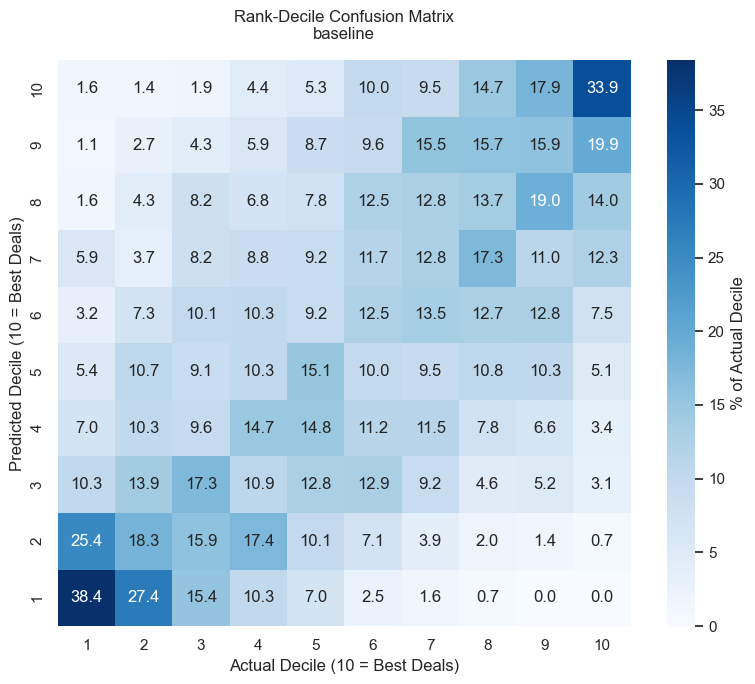

In [58]:
interactive_dataframe_selector(explorer.plot_rank_decile_matrix())

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('Gemma 4 Formative', 'Gemma 4 Ho…

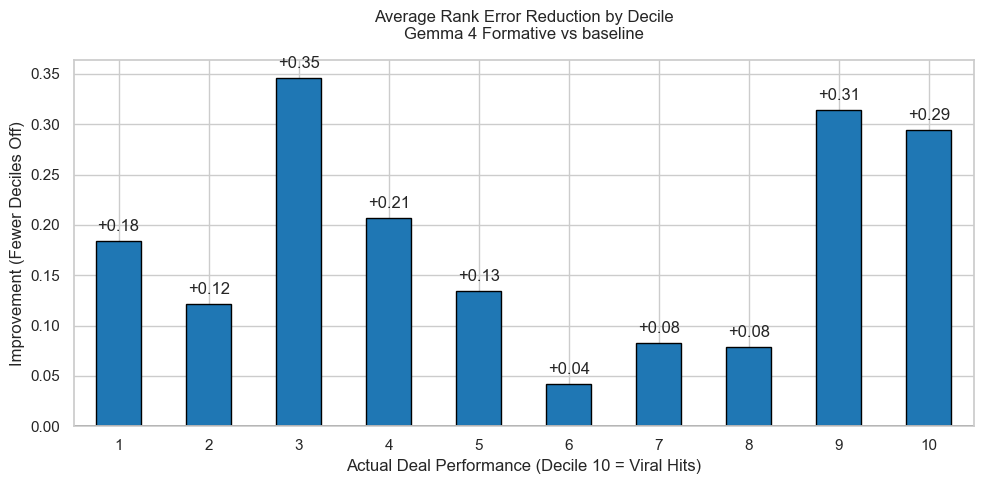

In [59]:
# 1. Generate the delta plots
decile_error_reduction_dict = explorer.plot_decile_error_reduction(
    baseline_label="baseline")

# 2. Render them interactively
interactive_dataframe_selector(decile_error_reduction_dict)

### Heteroskedasticity

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', 'Gemma 4 Formative',…

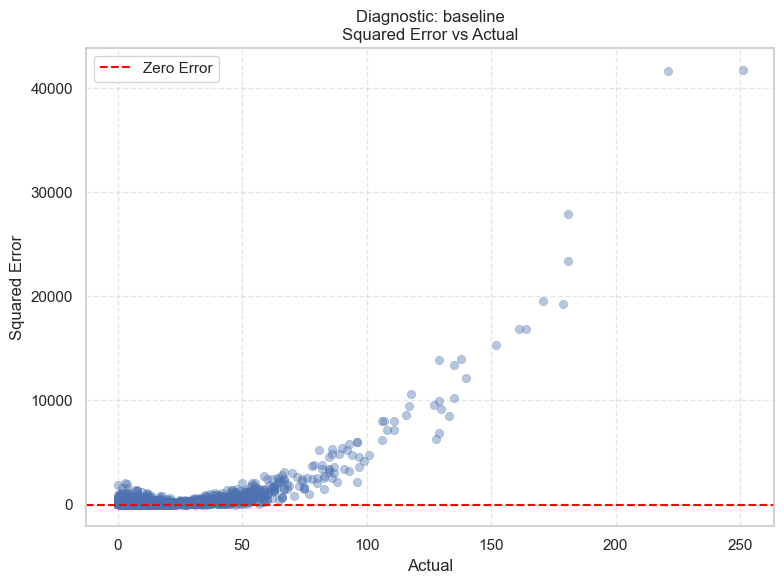

In [60]:
# 1. Diagnose heteroskedasticity (Does error variance explode at the right tail?)
sq_err_plots = explorer.plot_observation_level(x="actual", y="squared_error")

interactive_dataframe_selector(sq_err_plots)

### Rank degradation

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', 'Gemma 4 Formative',…

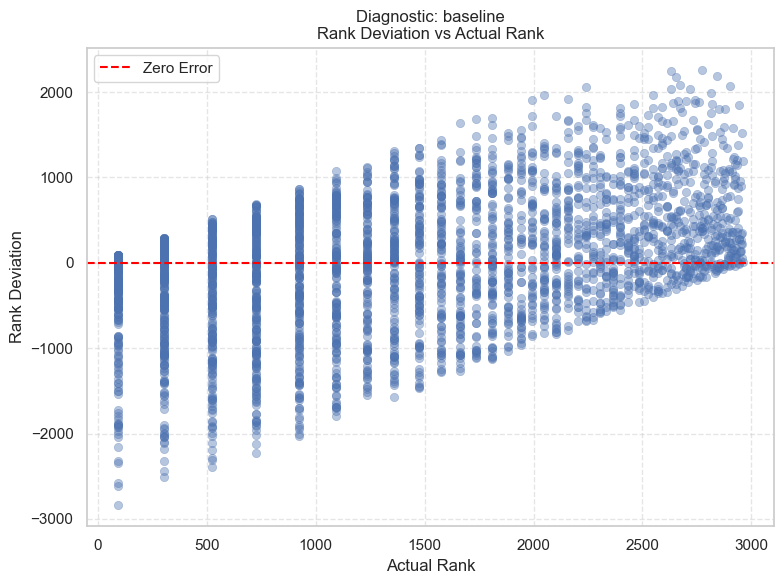

In [61]:
# 2. Diagnose rank degradation (Does the model fail strictly on magnitude, or does monotonic sorting break?)
# Plotting against actual_rank normalizes the x-axis to prevent visual crowding by extreme values
rank_dev_plots = explorer.plot_observation_level(
    x="actual_rank", y="rank_deviation")

interactive_dataframe_selector(rank_dev_plots)

### Prediction error

In [62]:
1 - 14.68/13.23

-0.1095993953136809

In [63]:
og_df.apps_after_7_days.median()

np.float64(8.0)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', 'Gemma 4 Formative',…

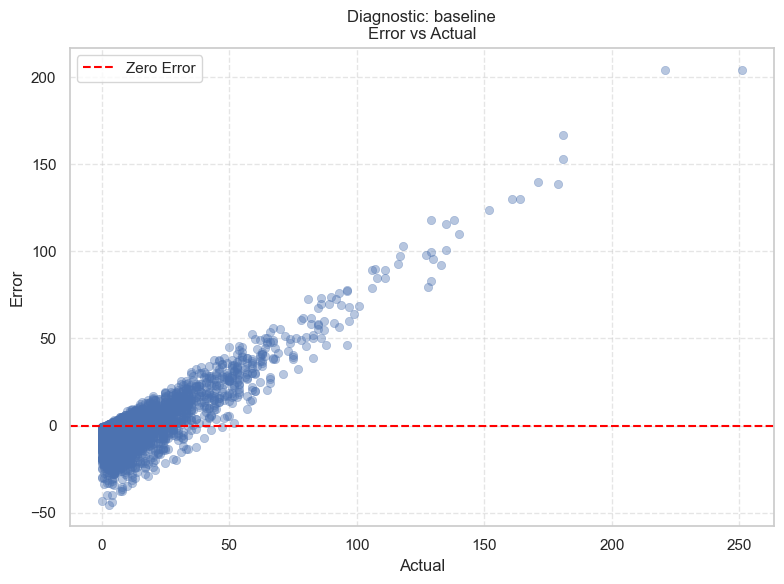

In [64]:
# 3. Assess absolute bias direction (Does it systematically underpredict high actuals?)
err_plots = explorer.plot_observation_level(x="actual", y="error")
interactive_dataframe_selector(err_plots)

Dropdown(description='Select option:', layout=Layout(width='400px'), options=('baseline', 'Gemma 4 Formative',…

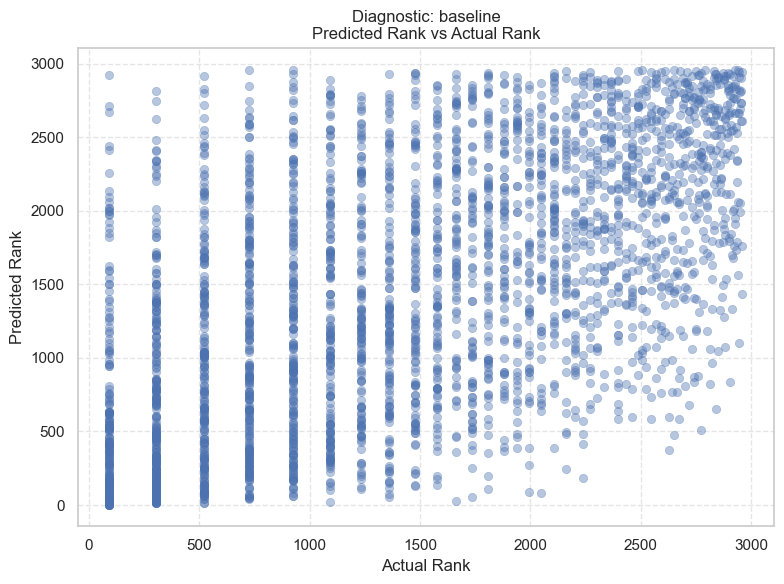

In [65]:
# This will generate exactly what ChatGPT asked for:
rank_scatter_figures = explorer.plot_observation_level(
    x="actual_rank",
    y="predicted_rank"
)
interactive_dataframe_selector(rank_scatter_figures)

## Inspect specific model failures

In [66]:
# Pass og_df to securely map the requirements text via deal_id
obs_df = explorer.get_observation_data(
    label="Qwen 3.5 Formative",
    merge_cols=["deal_text"],
    source_df=og_df
)

# Look at the exact same 5 false positives, but inspect their requirements
false_positives = obs_df.sort_values("rank_deviation", ascending=True).head(50)

for idx, row in false_positives.iterrows():
    print(
        f"--- Predicted Apps: {row['predicted']:.2f} | Follower Req: {row['strict_follower_requirement']} ---")
    print(f"Pitch: {str(row['deal_text'])[:150]}...")

--- Predicted Apps: 37.95 | Follower Req: 0.0 ---
Pitch: We’re inviting passionate UGC creators to collaborate with Wingman Condoms, the brand that makes protection smoother, easier, and more confident than ...
--- Predicted Apps: 33.52 | Follower Req: 0.0 ---
Pitch: What is in the deal? 1 drink + 1 pancake for the parent, all children up to and including 12 years old may choose from the kids menu. Want to bring mo...
--- Predicted Apps: 30.30 | Follower Req: 0.0 ---
Pitch: We’re looking for social media creators who would love to join us for a special wine tasting experience in the vineyards of Dörscheid.As part of this ...
--- Predicted Apps: 35.60 | Follower Req: 0.0 ---
Pitch: You’ll receive two of our best-selling drinking games plus €40 cash—perfect for hosting epic game nights and creating engaging video content that your...
--- Predicted Apps: 26.86 | Follower Req: 0.0 ---
Pitch: Bij Burger ’n Shake werken we graag samen met creators die onze passie voor goed eten, beleving en 

## Cross-validation

In [67]:
from src.barter.cross_validation import cross_validate_barter_models

model_configs = {
    'Baseline': None,
    'Z-Mean Only': ['z_mean_rating'],
    'Z-Mean + Entropy': ['z_mean_rating', 'normalized_entropy']
}

cv_results_df = cross_validate_barter_models(
    df=final_df,  # Use your combined dataframe
    target_col='apps_after_7_days',
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    model_configs=model_configs,
    n_splits=5
)

# Sort to easily see if Entropy improves the out-of-sample error
# print(cv_results_df.sort_values(['Experiment Group', 'RMSE (Mean)']))


--- Cross-validating group: ('Gemma 4', 'Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mean + Entropy CV complete.

--- Cross-validating group: ('Gemma 4', 'Holistic Naive') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mean + Entropy CV complete.

--- Cross-validating group: ('Gemma 4', 'Macro-Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mean + Entropy CV complete.

--- Cross-validating group: ('Llama 3.2', 'Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mean + Entropy CV complete.

--- Cross-validating group: ('Llama 3.2', 'Holistic Naive') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mean + Entropy CV complete.

--- Cross-validating group: ('Llama 3.2', 'Macro-Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mean + Entropy CV complete.

--- Cross-validating group: ('Qwen 3', 'Formative') ---
✓ Baseline CV complete.
✓ Z-Mean Only CV complete.
✓ Z-Mean + Entropy

In [68]:
cv_results_df

,Experiment Group,Model,RMSE (Mean),MAE (Mean),Poisson Dev (Mean),Pearson r (Mean),Spearman Rho (Mean),Kendall Tau (Mean)
0,Gemma 4 | Formative,Baseline,19.476527,11.703938,14.681921,0.392582,0.532587,0.377814
1,Gemma 4 | Formative,Z-Mean Only,18.881054,11.126928,13.228677,0.456139,0.600009,0.432289
2,Gemma 4 | Formative,Z-Mean + Entropy,18.857119,11.112976,13.203480,0.458711,0.599227,0.431772
3,Gemma 4 | Holistic Naive,Baseline,19.476562,11.703979,14.681985,0.392579,0.532578,0.377807
4,Gemma 4 | Holistic Naive,Z-Mean Only,19.470593,11.717246,14.599296,0.396125,0.538809,0.381246
5,Gemma 4 | Holistic Naive,Z-Mean + Entropy,19.475911,11.720490,14.611917,0.395728,0.539512,0.381713
6,Gemma 4 | Macro-Formative,Baseline,19.476523,11.703946,14.681928,0.392582,0.532580,0.377809
7,Gemma 4 | Macro-Formative,Z-Mean Only,19.505005,11.699291,14.637485,0.391647,0.535837,0.380541
8,Gemma 4 | Macro-Formative,Z-Mean + Entropy,19.506182,11.682905,14.675260,0.392597,0.537668,0.381810
9,Llama 3.2 | Formative,Baseline,19.476527,11.703938,14.681921,0.392582,0.532587,0.377814


In [69]:
print(cv_results_df.to_latex())

\begin{tabular}{lllrrrrrr}
\toprule
 & Experiment Group & Model & RMSE (Mean) & MAE (Mean) & Poisson Dev (Mean) & Pearson r (Mean) & Spearman Rho (Mean) & Kendall Tau (Mean) \\
\midrule
0 & Gemma 4 | Formative & Baseline & 19.476527 & 11.703938 & 14.681921 & 0.392582 & 0.532587 & 0.377814 \\
1 & Gemma 4 | Formative & Z-Mean Only & 18.881054 & 11.126928 & 13.228677 & 0.456139 & 0.600009 & 0.432289 \\
2 & Gemma 4 | Formative & Z-Mean + Entropy & 18.857119 & 11.112976 & 13.203480 & 0.458711 & 0.599227 & 0.431772 \\
3 & Gemma 4 | Holistic Naive & Baseline & 19.476562 & 11.703979 & 14.681985 & 0.392579 & 0.532578 & 0.377807 \\
4 & Gemma 4 | Holistic Naive & Z-Mean Only & 19.470593 & 11.717246 & 14.599296 & 0.396125 & 0.538809 & 0.381246 \\
5 & Gemma 4 | Holistic Naive & Z-Mean + Entropy & 19.475911 & 11.720490 & 14.611917 & 0.395728 & 0.539512 & 0.381713 \\
6 & Gemma 4 | Macro-Formative & Baseline & 19.476523 & 11.703946 & 14.681928 & 0.392582 & 0.532580 & 0.377809 \\
7 & Gemma 4 | Macro-Fo

6.X. Phase 2 Results: Predicting Market Liquidity

The transition from Phase 1 (explicit annotation) to Phase 2 (implicit market behavior) reveals a severe boundary condition for holistic LLM measurement. When tasked with predicting 7-day application counts for barter deals—a highly endogenous and unobservable construct—the holistic attention mechanism effectively collapsed.Evaluating predictive fit via out-of-sample Poisson Deviance (where lower values indicate superior distributional alignment), the baseline null model achieved a deviance of 15.32. Across all tested LLMs, the Holistic Naive specification struggled to extract meaningful market signal. For example, Qwen 3.5 reduced the deviance by a mere 0.37 points (14.95), while Llama 3.2 actually degraded predictive fit below the null baseline (15.35).However, imposing the formative decomposition structurally recovered the instrument's measurement capacity. The Qwen 3.5 Formative specification achieved a Poisson Deviance of 13.67—representing a predictive improvement more than four times larger than its holistic counterpart. This massive structural gap mathematically confirms that while modern LLMs can holistically evaluate simple, overt textual quality (as seen in Phase 1), they fail to implicitly weigh competing, multidimensional economic drivers. Architectural decomposition is therefore a strict requirement for extracting valid proxy measurements in complex behavioral domains.Finally, consistent with the expected-value saturation dynamic identified in Phase 1, the inclusion of measurement entropy yielded negligible or negative out-of-sample gains. Moving from the expected-value-only specification to the entropy-extended specification resulted in either degraded performance (Gemma-4) or marginal improvements (Qwen 3.5, $\Delta$ Deviance = 0.12) that were heavily dwarfed by the primary structural gains of the first moment.

Table X reports the cross-validated predictive performance of the Barter Deals models. Across all four evaluator families, the formative specification outperforms the base model, the holistic naive baseline, and the macro-formative baseline. The strongest performance is obtained by Qwen 3.5 in the formative condition, reducing mean Poisson deviance from 15.33 in the base model to 13.67 using EV scores alone, and to 13.54 when entropy is added. This corresponds to an out-of-sample deviance reduction of 10.8\% for the EV-only formative model and 11.6\% for the entropy-augmented model.

The gains in RMSE and MAE are smaller, indicating that exact point prediction of application counts remains difficult. This is expected given the overdispersed and stochastic nature of creator application behavior. The larger improvement in Poisson deviance suggests that the formative LLM measurements primarily improve the expected-rate structure of the count model rather than producing precise integer forecasts for individual Deals.

Entropy provides additional gains for the best-performing Qwen 3.5 formative model, but its effect is not consistent across all evaluators and conditions. The entropy results are therefore interpreted as exploratory support for the value of distributional information, while the main confirmatory finding is the consistent out-of-sample advantage of formative EV measurements.

# Mega model

In [70]:
from IPython.display import display, clear_output
import ipywidgets as widgets


prompts_to_include = final_df.prompt_id.unique().tolist()


mega_df = final_df


# 3. Create a single dummy group so the runner doesn't split the data
mega_df['mega_group'] = 'all_predictors'


# 1. Get all unique dimensions from your mega dataframe
all_variables = sorted(mega_df['analysis_group_full_clean'].unique().tolist())

# 2. Create the interactive multi-select widget
variable_selector = widgets.SelectMultiple(
    options=all_variables,
    value=all_variables,  # Default selects all of them (Kitchen Sink)
    rows=15,
    description='Variables:',
    layout=widgets.Layout(width='80%')
)

run_button = widgets.Button(
    description='Run Custom Model',
    button_style='success',
    icon='play'
)

output_area = widgets.Output()


def run_custom_regression(b):
    with output_area:
        clear_output(wait=True)
        selected_vars = list(variable_selector.value)

        if not selected_vars:
            print("⚠️ Please select at least one variable.")
            return

        print(
            f"🚀 Running OLS with {len(selected_vars)} selected dimensions...\n")

        # CORE MECHANIC: Filter the long dataframe to ONLY include selected variables
        # When the runner pivots this, the excluded variables simply won't exist!
        filtered_df = mega_df[mega_df['analysis_group_full_clean'].isin(
            selected_vars)].copy()

        # Re-initialize the runner
        custom_runner = create_regression_runner(
            target_col='apps_after_7_days',
            experimental_groups=['mega_group'],
            cluster_col='partner_id',
            model_type='negbin'
        )

        # Fit the model
        custom_runner.run_regression(
            df=filtered_df,
            cat_vars=CATEGORICALS,
            bin_vars=BINARIES,
            num_vars=CONTINUOUS,
            predictor_names=['z_mean_rating', 'normalized_entropy']
        )

        # Display the statsmodels summary table
        # The key is ('mega_group',) because of how groupby handles single-item lists

        # Safely attempt to fetch the result
        result = custom_runner.results.get('all_predictors')

        if result is not None:
            print(result.summary())
        else:
            print("🚨 MODEL FAILED TO CONVERGE.")
            print("Check for Perfect Multicollinearity. One of your binary variables (like friction) is likely all 0s, or a category has 0 observations.")
        # result = custom_runner.results["('all_predictors',)"]
        # if result:
        #     print(result.summary())
        # else:
        #     print("🚨 Model failed to converge. Check your variable mix.")


# 3. Render the UI
run_button.on_click(run_custom_regression)
display(variable_selector, run_button, output_area)

SelectMultiple(description='Variables:', index=(0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, …

Button(button_style='success', description='Run Custom Model', icon='play', style=ButtonStyle())

Output()

# Variable selection

In [71]:
runner_mean_fin = create_regression_runner(
    target_col='apps_after_7_days',  # Log-transformed target
    # target_col='log_apps_after_7_days',  # Log-transformed target
    experimental_groups=EXPERIMENTAL_GROUPS,
    cluster_col='partner_id',
    model_type='negbin',
)

runner_mean_fin.run_baseline_model(
    df=og_df,
    cat_vars=CATEGORICALS,
    bin_vars=BINARIES,
    num_vars=CONTINUOUS,
    label="baseline"
)

predictor_names = ['mean_rating']

runner_mean_fin.run_regression(df=final_df,
                               cat_vars=CATEGORICALS,
                               bin_vars=BINARIES,
                               num_vars=CONTINUOUS,
                               predictor_names=predictor_names)

✓ Baseline model fitted: 2960 observations, AIC=21056.41


In [72]:
from src.barter.model_selection import EconometricFeatureSelector


# 2. Instantiate the functional selector
selector = EconometricFeatureSelector(
    categoricals=CATEGORICALS,
    continuous=CONTINUOUS,
    binaries=BINARIES
)

In [73]:
# 3. Effortlessly test across runners and alphas with zero code duplication
final_result, final_features = selector.fit(
    runner=runner_mean_fin,  # Or runner_mean_entr
    target_model_label="Qwen 3.5 Formative",
    method="backward",
    alpha=0.05
)

# 4. Review your pristine, academically isolated summary
final_result.summary()

[START] Starting Backward Elimination (alpha = 0.05)
[INFO] Safely locked 38 structural baseline levels/features.

[-] Dropping 'deal_pitch_brand_prestige_mean_rating' (clustered p-value: 0.9910)
[-] Dropping 'deal_pitch_proposition_clarity_mean_rating' (clustered p-value: 0.8628)
[-] Dropping 'deal_pitch_workload_volume_mean_rating' (clustered p-value: 0.5976)
[-] Dropping 'deal_pitch_creator_brand_alignment_mean_rating' (clustered p-value: 0.3716)
[-] Dropping 'deal_pitch_creative_restrictiveness_mean_rating' (clustered p-value: 0.3467)
[-] Dropping 'deal_pitch_rhetorical_objectivity_mean_rating' (clustered p-value: 0.1597)

[SUCCESS] Optimization complete! Remaining experimental features satisfy alpha = 0.05.

FINAL OPTIMIZED MODEL: Qwen 3.5 Formative (BACKWARD)


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2960
Model:               NegativeBinomial   Df Residuals:                     2918
Method:                           MLE   Df Model:                           41
Date:                Wed, 01 Jul 2026   Pseudo R-squ.:                 0.07490
Time:                        17:42:27   Log-Likelihood:                -10277.
converged:                       True   LL-Null:                       -11109.
Covariance Type:              cluster   LLR p-value:                     0.000
===================================================================================================================
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
const                                               0.2633      0.282      0.935      0.350      -0.288       0.815
deal_pitch_call_to_action_strength_mean_rating      0.0847      0.028      3.025      0.002       0.030       0.140
deal_pitch_functional_utility_mean_rating          -0.0647      0.029     -2.235      0.025      -0.121      -0.008
deal_pitch_perceived_economic_value_mean_rating     0.1791      0.029      6.071      0.000       0.121       0.237
deal_pitch_product_universality_mean_rating         0.4598      0.035     13.088      0.000       0.391       0.529
strict_follower_requirement                        -0.2245      0.055     -4.066      0.000      -0.333      -0.116
competitor_density                                 -0.0380      0.007     -5.364      0.000      -0.052      -0.024
market_scope_Tier1_NonNLD_international            -1.2735      0.205     -6.218      0.000      -1.675      -0.872
market_scope_Tier2_NLD_only                        -0.3493      0.060     -5.849      0.000      -0.466      -0.232
market_scope_Tier3_BEL_Only                        -1.2192      0.141     -8.662      0.000      -1.495      -0.943
market_scope_Tier4_Germany                         -1.7109      0.076    -22.505      0.000      -1.860      -1.562
market_scope_Tier5_Other                           -1.3929      0.152     -9.188      0.000      -1.690      -1.096
macro_category_Beauty                               0.3797      0.178      2.128      0.033       0.030       0.729
macro_category_Digital Entertainment               -0.1255      0.184     -0.681      0.496      -0.487       0.236
macro_category_Dining & Hospitality                -0.1262      0.188     -0.671      0.502      -0.495       0.242
macro_category_Family & Parenting                  -0.0604      0.204     -0.296      0.767      -0.460       0.339
macro_category_Fashion                              0.2264      0.186      1.220      0.222      -0.137       0.590
macro_category_Home Cooking & CPG                   0.1469      0.180      0.816      0.414      -0.206       0.500
macro_category_In-Person Experiences               -0.4597      0.224     -2.053      0.040      -0.899      -0.021
macro_category_Lifestyle & Home                     0.4565      0.191      2.394      0.017       0.083       0.830
macro_category_Tech & Niche                        -0.2378      0.235     -1.013      0.311      -0.698       0.222
macro_category_Uncategorized                       -0.1504      0.229     -0.657      0.511      -0.599       0.298
year_month_2025-06                                  0.2395      0.094      2.551      0.011       0.055       0.423
year_month_2025-07                                  0.4282      0.097      4.413      0.000       0.238       0.618
year_month_2025-08                                  0.1584      0.103      1.537      0.124      -0.044      

In [74]:
# 3. Effortlessly test across runners and alphas with zero code duplication
final_result, final_features = selector.fit(
    runner=runner_mean_fin,  # Or runner_mean_entr
    target_model_label="Qwen 3.5 Formative",
    method="backward",
    alpha=0.05
)

# 4. Review your pristine, academically isolated summary
final_result.summary()

[START] Starting Backward Elimination (alpha = 0.05)
[INFO] Safely locked 38 structural baseline levels/features.

[-] Dropping 'deal_pitch_brand_prestige_mean_rating' (clustered p-value: 0.9910)
[-] Dropping 'deal_pitch_proposition_clarity_mean_rating' (clustered p-value: 0.8628)
[-] Dropping 'deal_pitch_workload_volume_mean_rating' (clustered p-value: 0.5976)
[-] Dropping 'deal_pitch_creator_brand_alignment_mean_rating' (clustered p-value: 0.3716)
[-] Dropping 'deal_pitch_creative_restrictiveness_mean_rating' (clustered p-value: 0.3467)
[-] Dropping 'deal_pitch_rhetorical_objectivity_mean_rating' (clustered p-value: 0.1597)

[SUCCESS] Optimization complete! Remaining experimental features satisfy alpha = 0.05.

FINAL OPTIMIZED MODEL: Qwen 3.5 Formative (BACKWARD)


<class 'statsmodels.iolib.summary.Summary'>
"""
                     NegativeBinomial Regression Results                      
==============================================================================
Dep. Variable:      apps_after_7_days   No. Observations:                 2960
Model:               NegativeBinomial   Df Residuals:                     2918
Method:                           MLE   Df Model:                           41
Date:                Wed, 01 Jul 2026   Pseudo R-squ.:                 0.07490
Time:                        17:42:29   Log-Likelihood:                -10277.
converged:                       True   LL-Null:                       -11109.
Covariance Type:              cluster   LLR p-value:                     0.000
===================================================================================================================
                                                      coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------
const                                               0.2633      0.282      0.935      0.350      -0.288       0.815
deal_pitch_call_to_action_strength_mean_rating      0.0847      0.028      3.025      0.002       0.030       0.140
deal_pitch_functional_utility_mean_rating          -0.0647      0.029     -2.235      0.025      -0.121      -0.008
deal_pitch_perceived_economic_value_mean_rating     0.1791      0.029      6.071      0.000       0.121       0.237
deal_pitch_product_universality_mean_rating         0.4598      0.035     13.088      0.000       0.391       0.529
strict_follower_requirement                        -0.2245      0.055     -4.066      0.000      -0.333      -0.116
competitor_density                                 -0.0380      0.007     -5.364      0.000      -0.052      -0.024
market_scope_Tier1_NonNLD_international            -1.2735      0.205     -6.218      0.000      -1.675      -0.872
market_scope_Tier2_NLD_only                        -0.3493      0.060     -5.849      0.000      -0.466      -0.232
market_scope_Tier3_BEL_Only                        -1.2192      0.141     -8.662      0.000      -1.495      -0.943
market_scope_Tier4_Germany                         -1.7109      0.076    -22.505      0.000      -1.860      -1.562
market_scope_Tier5_Other                           -1.3929      0.152     -9.188      0.000      -1.690      -1.096
macro_category_Beauty                               0.3797      0.178      2.128      0.033       0.030       0.729
macro_category_Digital Entertainment               -0.1255      0.184     -0.681      0.496      -0.487       0.236
macro_category_Dining & Hospitality                -0.1262      0.188     -0.671      0.502      -0.495       0.242
macro_category_Family & Parenting                  -0.0604      0.204     -0.296      0.767      -0.460       0.339
macro_category_Fashion                              0.2264      0.186      1.220      0.222      -0.137       0.590
macro_category_Home Cooking & CPG                   0.1469      0.180      0.816      0.414      -0.206       0.500
macro_category_In-Person Experiences               -0.4597      0.224     -2.053      0.040      -0.899      -0.021
macro_category_Lifestyle & Home                     0.4565      0.191      2.394      0.017       0.083       0.830
macro_category_Tech & Niche                        -0.2378      0.235     -1.013      0.311      -0.698       0.222
macro_category_Uncategorized                       -0.1504      0.229     -0.657      0.511      -0.599       0.298
year_month_2025-06                                  0.2395      0.094      2.551      0.011       0.055       0.423
year_month_2025-07                                  0.4282      0.097      4.413      0.000       0.238       0.618
year_month_2025-08                                  0.1584      0.103      1.537      0.124      -0.044      

Both forward and backwards result in the same model, pointing towards the robustness of this specification.

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Filter for Qwen 3.5 Formative data
# (Make sure 'Qwen 3.5 Formative' matches your exact column label for the model)
qwen_condition = final_df['model_name_clean'].str.contains(
    'Qwen 3.5', case=False, na=False)
qwen_df = final_df[qwen_condition].copy()

# Focus strictly on the 4 winning dimensions that survived selection
core_dimensions = [
    'deal_pitch_product_universality_mean',
    'deal_pitch_perceived_economic_value_mean',
    'deal_pitch_call_to_action_strength_mean',
    'deal_pitch_functional_utility_mean'
]

# Clean string matching check against your analysis groups
qwen_core = qwen_df[qwen_df['analysis_group_full_clean'].str.lower(
).str.contains('universality|economic|action|utility', na=False)].copy()

print("="*60)
print("QWEN 3.5 FORMATIVE: RAW RATING DESCRIPTIVE METRICS")
print("="*60)

# 2. Generate a clean summary table of the raw scale metrics
stats_table = qwen_core.groupby('analysis_group_full_clean')['mean_rating'].describe()[
    ['count', 'min', '25%', '50%', '75%', 'max', 'std']
]
# Add a Range column (Max - Min) to see the absolute spread
stats_table['range'] = stats_table['max'] - stats_table['min']
print(stats_table.round(2))

QWEN 3.5 FORMATIVE: RAW RATING DESCRIPTIVE METRICS
                                                     count   min   25%   50%  \
analysis_group_full_clean                                                      
Qwen 3.5: Formative\nCall To Action Strength(Fo...  2960.0  1.18  2.55  3.16   
Qwen 3.5: Formative\nFunctional Utility(Formative)  2960.0  1.21  2.67  3.46   
Qwen 3.5: Formative\nPerceived Economic Value(F...  2960.0  1.24  2.56  3.03   
Qwen 3.5: Formative\nProduct Universality(Forma...  2960.0  1.65  3.34  3.91   

                                                     75%   max   std  range  
analysis_group_full_clean                                                    
Qwen 3.5: Formative\nCall To Action Strength(Fo...  3.82  6.63  0.96   5.45  
Qwen 3.5: Formative\nFunctional Utility(Formative)  4.30  6.79  1.04   5.58  
Qwen 3.5: Formative\nPerceived Economic Value(F...  3.75  6.51  0.86   5.27  
Qwen 3.5: Formative\nProduct Universality(Forma...  4.42  5.92  0.75   4.27  
